# Classification with K-Nearest Neighbors (KNN) in R

This notebook demonstrates how to build a **K-Nearest Neighbors (KNN)** classification model in R using the `telecommunication_customer_churn.csv` dataset.

## Objectives
- Load and explore customer churn data
- Clean the dataset (handle missing values, remove irrelevant columns, fix column names)
- Encode categorical variables as dummy/indicator variables
- Normalize continuous features using Min-Max scaling
- Split data into training and test sets
- Build KNN and Logistic Regression classification models
- Evaluate models using confusion matrices, accuracy, classification reports, and ROC/AUC
- Tune KNN hyperparameters via grid search with cross-validation
- Compare model performance

---
## 1. Load Required Libraries

Before building any machine learning model, we need to load the appropriate R packages that provide the algorithms and utilities we'll use throughout this analysis.

### Libraries and Their Purposes:

| Package | Purpose |
|---------|---------|
| **class** | Provides the `knn()` function — the core K-Nearest Neighbors algorithm implementation |
| **caret** | Comprehensive framework for **C**lassification **A**nd **RE**gression **T**raining. Provides `train()` for hyperparameter tuning, `confusionMatrix()` for evaluation metrics, and cross-validation utilities |
| **pROC** | Creates **ROC (Receiver Operating Characteristic)** curves and calculates **AUC (Area Under Curve)** — essential metrics for evaluating binary classifiers |
| **ggplot2** | Grammar of Graphics plotting library for creating publication-quality visualizations |
| **dplyr** | Data manipulation toolkit (part of tidyverse) for filtering, selecting, and transforming data |
| **e1071** | Required dependency for some `caret` functions; provides additional ML algorithms |

### Why These Packages?
KNN is a **distance-based** algorithm, so we need tools for:
1. **Model Training**: `class::knn()` and `caret::train()` 
2. **Evaluation**: Confusion matrices, precision, recall, F1-score
3. **Visualization**: ROC curves and performance plots

In [21]:
# ============================================================================
# STEP 1: Install and Load Required Packages
# ============================================================================
# Define a vector of package names we need for this analysis
required_packages <- c("class", "caret", "pROC", "ggplot2", "dplyr", "e1071")

# Check which packages are NOT already installed
# installed.packages() returns a matrix of installed package info
# We extract the "Package" column and compare against our required list
new_packages <- required_packages[!(required_packages %in% installed.packages()[, "Package"])]

# Install any missing packages from CRAN (Comprehensive R Archive Network)
# Only runs if new_packages has at least one element
if (length(new_packages)) install.packages(new_packages, repos = "https://cloud.r-project.org")

# ----------------------------------------------------------------------------
# Load libraries into the R session
# library() attaches the package so its functions can be called directly
# ----------------------------------------------------------------------------
library(class)    # knn() - K-Nearest Neighbors classification algorithm
library(caret)    # train() - unified interface for model training with CV
                  # confusionMatrix() - generates accuracy, sensitivity, specificity, etc.
                  # trainControl() - defines cross-validation strategy
library(pROC)     # roc() - computes ROC curve coordinates
                  # auc() - calculates Area Under ROC Curve
library(ggplot2)  # ggplot() - grammar of graphics for elegant visualizations
library(dplyr)    # %>% pipe operator, select(), filter(), mutate() for data wrangling

---
## 2. Load the Dataset

### Dataset Overview: Telecommunication Customer Churn

We're working with a **customer churn prediction** dataset from a telecommunications company. **Churn** refers to customers who cancel or discontinue their service.

### Business Context:
- **Why predict churn?** Acquiring new customers costs 5-25x more than retaining existing ones
- Companies can use churn predictions to identify at-risk customers and offer targeted retention incentives
- This is a classic **binary classification** problem: predict `Churn = Yes` or `Churn = No`

### Data Loading Considerations:
| Parameter | Setting | Reason |
|-----------|---------|--------|
| `stringsAsFactors` | `FALSE` | Keeps character columns as strings so we can inspect and clean them before encoding |
| File path | `../data/module_4/` | Relative path from the Lecture folder to the data folder |

### Expected Dataset Structure:
- **Rows**: Individual customers (observations)
- **Columns**: Customer attributes (features) + Target variable (`Churn`)
- Common features: Demographics, service subscriptions, billing info, usage metrics

In [22]:
# ============================================================================
# STEP 2: Load the Customer Churn Dataset
# ============================================================================

# read.csv() - Base R function to read comma-separated values files
# Parameters:
#   - First arg: file path (relative or absolute)
#   - stringsAsFactors=FALSE: Don't auto-convert strings to factors
#     (Factors are categorical variables with fixed levels; we want manual control)
data <- read.csv("../data/module_4/telecommunication_customer_churn.csv",
                 stringsAsFactors = FALSE)

# Quick dimensionality check:
# nrow() returns number of observations (customers)
# ncol() returns number of variables (features + target)
cat("Dataset dimensions:", nrow(data), "rows x", ncol(data), "columns\n")

# INTERPRETATION:
# - Each row = one customer record
# - Each column = one feature (attribute) describing the customer
# - We need enough rows for reliable model training/testing (typically >1000)

Dataset dimensions: 10000 rows x 42 columns


---
## 3. Initial Data Exploration (EDA - Exploratory Data Analysis)

Before building any model, **Exploratory Data Analysis (EDA)** is crucial. We need to understand:

### Questions to Answer in EDA:

| Question | Why It Matters |
|----------|---------------|
| **What is the data structure?** | Identify data types (numeric, character, factor) to plan preprocessing |
| **Are there missing values?** | Missing data must be handled (imputation or removal) before KNN |
| **How many unique values per column?** | Helps distinguish categorical vs continuous features |
| **What's the target distribution?** | Class imbalance affects model training and evaluation |
| **Are there outliers?** | Outliers heavily impact distance-based algorithms like KNN |

### EDA Functions We'll Use:

| Function | Purpose | Output |
|----------|---------|--------|
| `head(df)` | View first 6 rows | Sample of data structure |
| `tail(df)` | View last 6 rows | Check for data loading issues at end |
| `str(df)` | Structure overview | Data types for each column |
| `summary(df)` | Statistical summary | Min, max, mean, quartiles for numeric; counts for factors |
| `is.na()` | Check for `NA` values | Boolean matrix of missing values |
| `unique()` | Distinct values | All unique entries in a column |

### Why EDA Before KNN Specifically?
- **KNN cannot handle missing values** — must be imputed or rows removed
- **KNN is distance-based** — features must be numeric and scaled appropriately
- **Categorical variables need encoding** — KNN works with numeric distances only

In [23]:
# ============================================================================
# STEP 3a: View First Few Rows with head()
# ============================================================================
# head(df, n) displays the first n rows (default n=6)
# This gives us a quick preview of:
#   - Column names and their formats
#   - Sample values to understand data content
#   - Whether the data loaded correctly (no parsing errors)
head(data)

# WHAT TO LOOK FOR:
# - Column names: Are they clean or do they have spaces/special characters?
# - Data types: Do numbers look like numbers? Dates like dates?
# - Missing indicators: Are there blanks, "NA", "N/A", "NULL" strings?

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,⋯,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,PaymentMethod,Tenure,MonthlyCharge,Bandwidth_GB_Year
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,1,K409198,aa90260b-4141-4a24-8e36-b04ce1f4f77b,e885b299883d4f9fb18e39c75155d990,Point Baker,AK,Prince of Wales-Hyder,99927,56.25100,-133.37571,⋯,Yes,No,No,No,Yes,Yes,Credit Card (automatic),6.795513,172.4555,904.5361
2,2,S120509,fb76459f-c047-4a9d-8af9-e0f7d4ac2524,f2de8bef964785f41a2959829830fb8a,West Branch,MI,Ogemaw,48661,44.32893,-84.24080,⋯,No,No,No,Yes,Yes,Yes,Bank Transfer(automatic),1.156681,242.6326,800.9828
3,3,K191035,344d114c-3736-4be5-98f7-c72c281e2d35,f1784cfa9f6d92ae816197eb175d3c71,Yamhill,OR,Yamhill,97148,45.35589,-123.24657,⋯,No,No,No,No,Yes,Yes,Credit Card (automatic),15.754144,159.9476,2054.7070
4,4,D90850,abfa2b40-2d43-4994-b15a-989b8c79e311,dc8a365077241bb5cd5ccd305136b05e,Del Mar,CA,San Diego,92014,32.96687,-117.24798,⋯,No,No,No,Yes,No,Yes,Mailed Check,17.087227,119.9568,2164.5794
5,5,K662701,68a861fd-0d20-4e51-a587-8a90407ee574,aabb64a116e83fdc4befc1fbab1663f9,Needville,TX,Fort Bend,77461,29.38012,-95.80673,⋯,No,No,Yes,Yes,No,No,Mailed Check,1.670972,149.9483,271.4934
6,6,W303516,2b451d12-6c2b-4cea-a295-ba1d6bced078,97598fd95658c80500546bc1dd312994,Fort Valley,GA,Peach,31030,32.57032,-83.89040,⋯,Yes,Yes,No,No,Yes,No,Electronic Check,7.000994,185.0077,1039.3580


In [24]:
# ============================================================================
# STEP 3b: View Last Few Rows with tail()
# ============================================================================
# tail(df, n) displays the last n rows (default n=6)
# This is useful to check:
#   - If data loaded completely (no truncation)
#   - If there are any summary/footer rows that shouldn't be data
#   - Whether patterns change at the end of the dataset
tail(data)

# TIP: If head() and tail() show different column patterns,
# there might be data quality issues to investigate

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,⋯,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,PaymentMethod,Tenure,MonthlyCharge,Bandwidth_GB_Year
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
9995,9995,P175475,c60df12b-a50b-4397-ae57-98381a0d3960,0ebfa51b03465a2ddb17884bbb4eabb6,West Kill,NY,Greene,12492,42.18491,-74.33574,⋯,No,Yes,No,No,Yes,No,Credit Card (automatic),49.92156,142.4827,4945.756
9996,9996,M324793,45deb5a2-ae04-4518-bf0b-c82db8dbe4a4,9499fb4de537af195d16d046b79fd20a,Mount Holly,VT,Rutland,5758,43.43391,-72.78734,⋯,Yes,Yes,No,No,No,No,Electronic Check,68.19713,159.9794,6511.253
9997,9997,D861732,6e96b921-0c09-4993-bbda-a1ac6411061a,c09a841117fa81b5c8e19afec2760104,Clarksville,TN,Montgomery,37042,36.56907,-87.41694,⋯,Yes,Yes,No,Yes,No,No,Electronic Check,61.04037,207.4811,5695.952
9998,9998,I243405,e8307ddf-9a01-4fff-bc59-4742e03fd24f,9c41f212d1e04dca84445019bbc9b41c,Mobeetie,TX,Wheeler,79061,35.52039,-100.44180,⋯,Yes,No,No,No,No,Yes,Bank Transfer(automatic),47.41689,169.9741,4159.306
9999,9999,I641617,3775ccfc-0052-4107-81ae-9657f81ecdf3,3e1f269b40c235a1038863ecf6b7a0df,Carrollton,GA,Carroll,30117,33.58016,-85.13241,⋯,No,No,Yes,Yes,Yes,Yes,Credit Card (automatic),71.09560,252.6240,6468.457
10000,10000,T38070,9de5fb6e-bd33-4995-aec8-f01d0172a499,0ea683a03a3cd544aefe8388aab16176,Clarkesville,GA,Habersham,30523,34.70783,-83.53648,⋯,Yes,Yes,No,No,Yes,Yes,Electronic Check,63.35086,217.4840,5857.586


In [25]:
# ============================================================================
# STEP 3c: Examine Data Structure with str()
# ============================================================================
# str() provides a compact display of the internal structure showing:
#   - Object type (data.frame, list, etc.)
#   - Number of observations and variables
#   - Column names with data types (int, num, chr, Factor, etc.)
#   - First few values of each column
str(data)

# DATA TYPE REFERENCE:
# - int    : Integer (whole numbers)
# - num    : Numeric (decimal/floating point)
# - chr    : Character (text strings)
# - Factor : Categorical with defined levels
# - logi   : Logical (TRUE/FALSE)

# FOR KNN: We need to convert chr columns to numeric via dummy encoding

'data.frame':	10000 obs. of  42 variables:
 $ CaseOrder           : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Customer_id         : chr  "K409198" "S120509" "K191035" "D90850" ...
 $ Interaction         : chr  "aa90260b-4141-4a24-8e36-b04ce1f4f77b" "fb76459f-c047-4a9d-8af9-e0f7d4ac2524" "344d114c-3736-4be5-98f7-c72c281e2d35" "abfa2b40-2d43-4994-b15a-989b8c79e311" ...
 $ UID                 : chr  "e885b299883d4f9fb18e39c75155d990" "f2de8bef964785f41a2959829830fb8a" "f1784cfa9f6d92ae816197eb175d3c71" "dc8a365077241bb5cd5ccd305136b05e" ...
 $ City                : chr  "Point Baker" "West Branch" "Yamhill" "Del Mar" ...
 $ State               : chr  "AK" "MI" "OR" "CA" ...
 $ County              : chr  "Prince of Wales-Hyder" "Ogemaw" "Yamhill" "San Diego" ...
 $ Zip                 : int  99927 48661 97148 92014 77461 31030 37847 73109 34771 45237 ...
 $ Lat                 : num  56.3 44.3 45.4 33 29.4 ...
 $ Lng                 : num  -133.4 -84.2 -123.2 -117.2 -95.8 ...
 $ Population         

In [26]:
# ============================================================================
# STEP 3d: Check for Missing Values (NA)
# ============================================================================
# is.na(data) creates a logical matrix: TRUE where value is NA, FALSE otherwise
# colSums() adds up each column — since TRUE=1 and FALSE=0, this counts NAs

na_counts <- colSums(is.na(data))

# Display only columns that HAVE missing values (count > 0)
cat("Columns with missing values:\n")
print(na_counts[na_counts > 0])

# Grand total of missing values across entire dataset
cat("\nTotal missing values:", sum(is.na(data)), "\n")

# WHY THIS MATTERS FOR KNN:
# KNN calculates distances between data points. If a feature has NA:
#   - We can't compute distance for that dimension
#   - Options: 1) Remove rows with NA, 2) Impute (fill in) missing values
# We'll handle this in the Data Cleaning section

Columns with missing values:
named numeric(0)

Total missing values: 0 


In [27]:
# ============================================================================
# STEP 3e: Count Unique Values Per Column
# ============================================================================
# sapply() applies a function to each column of the data frame
# unique(x) returns only distinct values; length() counts them

sapply(data, function(x) length(unique(x)))

# INTERPRETATION GUIDE:
# - 2-10 unique values → Likely CATEGORICAL (e.g., Gender: Male/Female)
# - 10-50 unique values → Could be categorical or ordinal
# - 50+ unique values → Likely CONTINUOUS (e.g., Income, Age)
# - n == nrow(data) → Probably a unique ID column (should be REMOVED)

# This helps us plan:
# - Which columns to one-hot encode (categorical)
# - Which columns to normalize (continuous)
# - Which columns to drop (IDs, high-cardinality fields)

CaseOrder          Customer_id          Interaction 
               10000                10000                10000 
                 UID                 City                State 
               10000                 6058                   52 
              County                  Zip                  Lat 
                1620                 8583                 8563 
                 Lng           Population                 Area 
                8630                 5933                    3 
            TimeZone                  Job             Children 
                  25                  639                   11 
                 Age               Income              Marital 
                  72                 9993                    5 
              Gender                Churn   Outage_sec_perweek 
                   3                    2                 9986 
               Email             Contacts Yearly_equip_failure 
                  23                    8                    6 
              Techie             Contract           Port_modem 
                   2                    3                    2 
              Tablet      InternetService                Phone 
                   2                    3                    2 
            Multiple       OnlineSecurity         OnlineBackup 
                   2                    2                    2 
    DeviceProtection          TechSupport          StreamingTV 
                   2                    2                    2 
     StreamingMovies     PaperlessBilling        PaymentMethod 
                   2                    2                    4 
              Tenure        MonthlyCharge    Bandwidth_GB_Year 
                9996                  750                10000

In [28]:
# ============================================================================
# STEP 3f: Inspect Unique Values for Low-Cardinality Columns
# ============================================================================
# For columns with <100 unique values, print all distinct values
# This helps us understand categorical variable levels

for (col in names(data)) {
  # Get count of unique values in this column
  n_unique <- length(unique(data[[col]]))
  
  # Only print if reasonably few unique values (likely categorical)
  if (n_unique < 100) {
    # sort() arranges values alphabetically/numerically for easier reading
    cat(col, ":", sort(unique(data[[col]])), "\n\n")
  }
}

# WHAT TO LOOK FOR:
# - Binary fields (Yes/No, True/False, 0/1) - common for flags
# - Multi-level categories (e.g., PaymentMethod: "Credit Card", "Bank Transfer", "Cash")
# - Ordinal data (e.g., Contract: "Month-to-month", "One year", "Two year")
# - Target variable (Churn): Check for class balance

State : AK AL AR AZ CA CO CT DC DE FL GA HI IA ID IL IN KS KY LA MA MD ME MI MN MO MS MT NC ND NE NH NJ NM NV NY OH OK OR PA PR RI SC SD TN TX UT VA VT WA WI WV WY 

Area : Rural Suburban Urban 

TimeZone : America/Anchorage America/Boise America/Chicago America/Denver America/Detroit America/Indiana/Indianapolis America/Indiana/Knox America/Indiana/Marengo America/Indiana/Petersburg America/Indiana/Tell_City America/Indiana/Vincennes America/Indiana/Winamac America/Juneau America/Kentucky/Louisville America/Los_Angeles America/Menominee America/New_York America/Nome America/North_Dakota/New_Salem America/Ojinaga America/Phoenix America/Puerto_Rico America/Sitka America/Toronto Pacific/Honolulu 

Children : 0 1 2 3 4 5 6 7 8 9 10 

Age : 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 

Marital : Divorced Married Never M

---
## 4. Data Cleaning

Data cleaning is a **critical preprocessing step** — especially for KNN, which is sensitive to data quality issues.

### 4a. Fix Column Names
**Problem:** Column names with spaces, parentheses, or special characters cause issues in R formulas and can break code.

**Solution:** Replace problematic characters with underscores using `gsub()` (global substitution with regex).

| Original | Cleaned | Character Replaced |
|----------|---------|-------------------|
| `Total Charges` | `Total_Charges` | space → underscore |
| `Usage (GB)` | `Usage_GB` | parentheses removed |
| `Day/Night` | `Day_Night` | slash → underscore |

---

### 4b. Handle Missing Values (NA Imputation)

**Problem:** The `InternetService` column has **2,129 missing values**.

**Domain Knowledge Insight:** In telecom data, customers with `NA` for internet service typically mean they **haven't subscribed** to internet — not that data is missing.

**Solution:** Impute `NA` values as `"None"` — a valid category indicating no service.

```r
# Imputation formula:
data$InternetService[is.na(data$InternetService)] <- "None"
```

**Alternative Approaches for Missing Values:**
| Method | When to Use |
|--------|-------------|
| **Impute with "None"** | When NA has semantic meaning (our case) |
| **Impute with mean/median** | Continuous variables with random missingness |
| **Impute with mode** | Categorical variables |
| **Remove rows** | When <5% of data is missing |
| **Use KNN imputation** | When relationships exist between features |

---

### 4c. Drop Irrelevant Columns

**Problem:** Some columns are **not useful for prediction** and can even hurt model performance:

| Column Type | Examples | Why Remove |
|-------------|----------|-----------|
| **Identifiers** | `Customer_id`, `UID` | Unique per row; no predictive value |
| **High-cardinality** | `City`, `Zip`, `Job` | Too many levels → sparse one-hot encoding |
| **Geographic details** | `Lat`, `Lng`, `State` | Not generalizable; causes overfitting |
| **Arbitrary ordering** | `CaseOrder`, `Interaction` | Internal IDs without meaning |

**Rule of Thumb:** If a column wouldn't help a human predict churn, it probably won't help the model.

In [29]:
# ============================================================================
# STEP 4a: Clean Column Names
# ============================================================================
# Define a function to standardize column names across the data frame
# This makes columns easier to reference in formulas and code

clean_column_names <- function(df) {
  # gsub(pattern, replacement, x) performs global substitution
  # [[:space:]]+ matches one or more whitespace characters (spaces, tabs)
  names(df) <- gsub("[[:space:]]+", "_", names(df))   # spaces → underscore
  
  # [()] matches literal parentheses characters
  names(df) <- gsub("[()]", "", names(df))             # remove ( and )
  
  # [,/] matches commas or forward slashes
  names(df) <- gsub("[,/]", "_", names(df))            # comma/slash → underscore
  
  return(df)
}

# Apply the cleaning function to our data frame
data <- clean_column_names(data)

# Display the cleaned column names
cat("Column names after cleaning:\n")
print(names(data))

# NOTE: R allows $col_name syntax only for valid R names (letters, numbers, dots, underscores)
# So "Total Charges" → data$Total_Charges now works properly

Column names after cleaning:
 [1] "CaseOrder"            "Customer_id"          "Interaction"         
 [4] "UID"                  "City"                 "State"               
 [7] "County"               "Zip"                  "Lat"                 
[10] "Lng"                  "Population"           "Area"                
[13] "TimeZone"             "Job"                  "Children"            
[16] "Age"                  "Income"               "Marital"             
[19] "Gender"               "Churn"                "Outage_sec_perweek"  
[22] "Email"                "Contacts"             "Yearly_equip_failure"
[25] "Techie"               "Contract"             "Port_modem"          
[28] "Tablet"               "InternetService"      "Phone"               
[31] "Multiple"             "OnlineSecurity"       "OnlineBackup"        
[34] "DeviceProtection"     "TechSupport"          "StreamingTV"         
[37] "StreamingMovies"      "PaperlessBilling"     "PaymentMethod"       
[40] "Ten

In [30]:
# ============================================================================
# STEP 4b: Handle Missing Values in InternetService
# ============================================================================
# DOMAIN KNOWLEDGE: In telecom, NA for InternetService typically means
# the customer doesn't have internet service (not that data is unknown)
# So we impute with "None" as a valid category

# Check count BEFORE imputation
cat("InternetService NAs before imputation:", sum(is.na(data$InternetService)), "\n")

# IMPUTATION: Replace all NA values with "None"
# Syntax: df$column[condition] <- new_value
# is.na() returns TRUE for NA values, which we use as an index
data$InternetService[is.na(data$InternetService)] <- "None"

# Verify imputation worked
cat("InternetService NAs after imputation:", sum(is.na(data$InternetService)), "\n")

# Show the updated categories
cat("InternetService values now:", unique(data$InternetService), "\n")

# WHY "None" INSTEAD OF REMOVING ROWS?
# - Removing 2,129 rows would lose ~21% of our data
# - "None" is meaningful: these customers are potential upsell targets
# - The model can learn if "no internet" correlates with churn behavior

InternetService NAs before imputation: 0 
InternetService NAs after imputation: 0 
InternetService values now: Fiber Optic DSL None 


In [31]:
# ============================================================================
# STEP 4b (continued): Verify No Remaining Missing Values
# ============================================================================
# After imputation, confirm the dataset is complete (no NAs)

cat("Total remaining NAs:", sum(is.na(data)), "\n")

# If this is 0, we're ready for modeling
# If not 0, we need to investigate and handle additional missing values

Total remaining NAs: 0 


In [32]:
# ============================================================================
# STEP 4c: Drop Irrelevant/High-Cardinality Columns
# ============================================================================
# These columns won't help predict churn and may cause problems:
# - Identifiers: Customer_id, UID, CaseOrder, Interaction
# - High-cardinality: City, County, Zip, Job (too many unique values)
# - Geographic: State, Lat, Lng, TimeZone (not generalizable)

to_drop <- c("City", "County", "Zip", "Job", "TimeZone",
             "Lat", "Lng", "UID", "Customer_id",
             "Interaction", "CaseOrder", "State")

# SUBSETTING with %in% operator:
# names(data) %in% to_drop returns TRUE/FALSE for each column
# !(...)  negates: TRUE becomes FALSE and vice versa
# So we KEEP columns that are NOT in the to_drop list
data <- data[, !(names(data) %in% to_drop)]

# Result check
cat("Remaining columns:", ncol(data), "\n")
print(names(data))

# ALTERNATIVE SYNTAX (dplyr):
# data <- select(data, -all_of(to_drop))

Remaining columns: 30 
 [1] "Population"           "Area"                 "Children"            
 [4] "Age"                  "Income"               "Marital"             
 [7] "Gender"               "Churn"                "Outage_sec_perweek"  
[10] "Email"                "Contacts"             "Yearly_equip_failure"
[13] "Techie"               "Contract"             "Port_modem"          
[16] "Tablet"               "InternetService"      "Phone"               
[19] "Multiple"             "OnlineSecurity"       "OnlineBackup"        
[22] "DeviceProtection"     "TechSupport"          "StreamingTV"         
[25] "StreamingMovies"      "PaperlessBilling"     "PaymentMethod"       
[28] "Tenure"               "MonthlyCharge"        "Bandwidth_GB_Year"   


In [33]:
# ============================================================================
# STEP 4d: Check for Duplicate Rows
# ============================================================================
# duplicated() returns TRUE for all rows that are exact copies of earlier rows
# sum() counts how many TRUE values (duplicate rows)

cat("Duplicate rows:", sum(duplicated(data)), "\n")

# WHY CHECK FOR DUPLICATES?
# - Duplicates can artificially inflate model performance
# - KNN with duplicates: same points appear multiple times in nearest neighbors
# - If duplicates exist, consider: data$unique <- data[!duplicated(data), ]

Duplicate rows: 0 


In [34]:
# ============================================================================
# STEP 4e: Summary Statistics of Cleaned Data
# ============================================================================
# summary() provides different statistics based on column type:
# - Numeric: Min, 1st Qu., Median, Mean, 3rd Qu., Max
# - Character/Factor: Length, class, mode (or level counts for factors)

summary(data)

# WHAT TO LOOK FOR:
# - Numeric ranges: Are scales vastly different? (e.g., Age: 0-100, Income: 0-500000)
#   → This is why we need NORMALIZATION for KNN
# - Outliers: Is Max much larger than 3rd Quartile? (potential outliers)
# - Target balance: How many "Yes" vs "No" in Churn?
#   → Imbalanced data may need special handling

   Population         Area              Children           Age       
 Min.   :     0   Length:10000       Min.   : 0.000   Min.   :18.00  
 1st Qu.:   738   Class :character   1st Qu.: 0.000   1st Qu.:35.00  
 Median :  2910   Mode  :character   Median : 1.000   Median :53.00  
 Mean   :  9757                      Mean   : 2.088   Mean   :53.08  
 3rd Qu.: 13168                      3rd Qu.: 3.000   3rd Qu.:71.00  
 Max.   :111850                      Max.   :10.000   Max.   :89.00  
     Income           Marital             Gender             Churn          
 Min.   :   348.7   Length:10000       Length:10000       Length:10000      
 1st Qu.: 19224.7   Class :character   Class :character   Class :character  
 Median : 33170.6   Mode  :character   Mode  :character   Mode  :character  
 Mean   : 39806.9                                                           
 3rd Qu.: 53246.2                                                           
 Max.   :258900.7                               

---
## 5. Feature Engineering — Dummy Variables & Normalization

**Feature engineering** transforms raw data into a format suitable for machine learning algorithms. For KNN, this is especially critical because:

### Why KNN Requires Special Preprocessing

**KNN is a distance-based algorithm** — it classifies new points based on the majority class among the `k` nearest training points. Distance is typically calculated using Euclidean distance:

$$d(x, y) = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$$

---

### 5a. One-Hot Encoding (Dummy Variables)

**Problem:** KNN can only compute distances between **numeric** values. Categorical variables like `Gender = "Male"` or `Contract = "Two year"` have no inherent numeric meaning.

**Solution:** **One-hot encoding** creates binary (0/1) columns for each category level:

| Original | Encoded Columns |
|----------|-----------------|
| Gender = "Male" | Gender_Male = 1, Gender_Female = 0 |
| Gender = "Female" | Gender_Male = 0, Gender_Female = 1 |
| Contract = "Month-to-month" | Contract_Month = 1, Contract_Year = 0, Contract_TwoYear = 0 |

**R Function:** `model.matrix(~ var1 + var2, data)` automatically creates dummy variables

---

### 5b. Min-Max Normalization (Feature Scaling)

**Problem:** Features with different scales dominate the distance calculation.

**Example without scaling:**
- Income: ranges from $20,000 to $200,000 (range = 180,000)
- Age: ranges from 18 to 80 (range = 62)
- Distance formula is dominated by Income because its values are ~3000x larger!

**Solution:** **Min-Max scaling** transforms all features to the same range [0, 1]:

$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

| Before Scaling | After Scaling |
|---------------|---------------|
| Income = $100,000 | Income = 0.44 |
| Age = 45 | Age = 0.44 |
| Now both contribute equally to distance! |

---

### Feature Type Summary for This Dataset:

| Feature Type | Examples | Preprocessing |
|-------------|----------|---------------|
| **Categorical** | Gender, Contract, PaymentMethod | One-hot encode |
| **Continuous** | Income, Age, MonthlyCharge | Min-Max normalize |
| **Target** | Churn | Convert to binary (0/1) |

In [35]:
# ============================================================================
# STEP 5a: Define Categorical and Continuous Columns
# ============================================================================
# We need to specify which columns require which type of preprocessing

# CATEGORICAL COLUMNS → Will be one-hot encoded (dummy variables)
# These are columns with discrete categories (not numbers you can average)
categorical_cols <- c("Area", "Marital", "Gender", "Techie", "Contract",
                      "Port_modem", "Tablet", "InternetService", "Phone",
                      "Multiple", "OnlineSecurity", "OnlineBackup",
                      "DeviceProtection", "TechSupport", "StreamingTV",
                      "StreamingMovies", "PaperlessBilling", "PaymentMethod")

# CONTINUOUS COLUMNS → Will be Min-Max normalized to [0, 1]
# These are numeric columns where mathematical operations make sense
continuous_cols <- c("Population", "Children", "Age", "Income",
                     "Outage_sec_perweek", "Email", "Contacts",
                     "Yearly_equip_failure", "Tenure",
                     "MonthlyCharge", "Bandwidth_GB_Year")

# VERIFICATION: Print counts
cat("Categorical features:", length(categorical_cols), "\n")
cat("Continuous features:", length(continuous_cols), "\n")

Categorical features: 18 
Continuous features: 11 


In [36]:
# ============================================================================
# STEP 5b: Extract and Encode the Target Variable (Churn)
# ============================================================================
# The target variable needs to be separated from features and encoded as numeric

# ifelse(condition, value_if_true, value_if_false) is R's vectorized ternary operator
# Convert "Yes" → 1 (churned) and "No" → 0 (retained)
y <- ifelse(data$Churn == "Yes", 1, 0)

# Check the distribution of the target variable
cat("Target distribution:\n")
table(y)

# INTERPRETATION:
# - 0 = Customer stayed (negative class)
# - 1 = Customer churned (positive class - what we're trying to predict)
# - Ratio tells us about CLASS BALANCE
#   - Balanced: ~50/50 → standard modeling
#   - Imbalanced: e.g., 90/10 → may need SMOTE, class weights, or stratified sampling

Target distribution:


y
   0    1 
7350 2650 

In [37]:
# ============================================================================
# STEP 5c: One-Hot Encode Categorical Variables
# ============================================================================
# model.matrix() creates a design matrix for regression, which automatically
# converts factors/characters to dummy variables

# Remove Churn from features (we've already extracted it to y)
data$Churn <- NULL

# BUILD THE FORMULA DYNAMICALLY:
# We need a formula like: ~ Area + Marital + Gender + ... + PaymentMethod
# paste() with collapse=" + " joins column names with " + " between them
formula_str <- paste("~ ", paste(categorical_cols, collapse = " + "))
cat("One-hot encoding formula:", formula_str, "\n\n")

# CREATE DUMMY VARIABLES:
# model.matrix() creates the design matrix
# as.formula() converts our string to a formula object
# [, -1] removes the intercept column (first column of all 1s)
dummy_matrix <- model.matrix(as.formula(formula_str), data = data)[, -1]

# COMBINE with continuous columns into final feature matrix X
# cbind() binds columns together horizontally
X <- cbind(data[, continuous_cols], dummy_matrix)

# CLEAN COLUMN NAMES:
# make.names() ensures all names are valid R identifiers
# unique=TRUE adds suffixes if there are duplicates
names(X) <- make.names(names(X), unique = TRUE)

# RESULT CHECK:
cat("Feature matrix dimensions:", nrow(X), "rows x", ncol(X), "columns\n")
cat("\nFirst 10 columns preview:\n")
head(X[, 1:10])  # Show first 10 columns to verify structure

One-hot encoding formula: ~  Area + Marital + Gender + Techie + Contract + Port_modem + Tablet + InternetService + Phone + Multiple + OnlineSecurity + OnlineBackup + DeviceProtection + TechSupport + StreamingTV + StreamingMovies + PaperlessBilling + PaymentMethod 

Feature matrix dimensions: 10000 rows x 38 columns



First 10 columns preview:


,Population,Children,Age,Income,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Tenure,MonthlyCharge
,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>
1,38,0,68,28561.99,7.978323,10,0,1,6.795513,172.4555
2,10446,1,27,21704.77,11.699080,12,0,1,1.156681,242.6326
3,3735,4,50,9609.57,10.752800,9,0,1,15.754144,159.9476
4,13863,1,48,18925.23,14.913540,15,2,0,17.087227,119.9568
5,11352,0,83,40074.19,8.147417,16,2,1,1.670972,149.9483
6,17701,3,83,22660.20,8.420993,15,3,1,7.000994,185.0077


In [38]:
# ============================================================================
# STEP 5d: Min-Max Normalize Continuous Features
# ============================================================================
# Scale all continuous features to the range [0, 1] so no feature dominates
# the distance calculation

# DEFINE THE MIN-MAX SCALING FUNCTION:
# Formula: (x - min) / (max - min)
# - Input: a numeric vector x
# - Output: scaled vector where min→0 and max→1
min_max_scale <- function(x) {
  # na.rm = TRUE ignores NA values when computing min/max
  (x - min(x, na.rm = TRUE)) / (max(x, na.rm = TRUE) - min(x, na.rm = TRUE))
}

# APPLY NORMALIZATION to only the continuous columns
# lapply() applies a function to each element of a list/data frame
# We assign the result back to the same columns
X[, continuous_cols] <- lapply(X[, continuous_cols], min_max_scale)

# VERIFY: All continuous features should now be in [0, 1]
cat("After normalization — summary of first 5 continuous features:\n")
summary(X[, continuous_cols[1:5]])

# NOTE ON DUMMY VARIABLES:
# One-hot encoded columns are already 0/1, so no scaling needed
# This is why we only apply min_max_scale to continuous_cols

After normalization — summary of first 5 continuous features:


   Population          Children           Age             Income       
 Min.   :0.000000   Min.   :0.0000   Min.   :0.0000   Min.   :0.00000  
 1st Qu.:0.006598   1st Qu.:0.0000   1st Qu.:0.2394   1st Qu.:0.07301  
 Median :0.026021   Median :0.1000   Median :0.4930   Median :0.12695  
 Mean   :0.087229   Mean   :0.2088   Mean   :0.4941   Mean   :0.15261  
 3rd Qu.:0.117729   3rd Qu.:0.3000   3rd Qu.:0.7465   3rd Qu.:0.20459  
 Max.   :1.000000   Max.   :1.0000   Max.   :1.0000   Max.   :1.00000  
 Outage_sec_perweek
 Min.   :0.0000    
 1st Qu.:0.3751    
 Median :0.4699    
 Mean   :0.4691    
 3rd Qu.:0.5623    
 Max.   :1.0000    

---
## 6. Train/Test Split

**Why split the data?** We need to evaluate our model on data it has never seen during training. This simulates how the model will perform on new, future customers.

### The Holdout Method

```
Total Data (10,000 customers)
    │
    ├── Training Set (70% = 7,000) → Used to train/fit the model
    │
    └── Test Set (30% = 3,000) → Used ONLY for final evaluation
```

### Split Ratio Considerations:

| Split | Training | Testing | When to Use |
|-------|----------|---------|-------------|
| **70/30** | 70% | 30% | Standard choice for medium datasets |
| 80/20 | 80% | 20% | When you have lots of data |
| 60/40 | 60% | 40% | When you need reliable test estimates |

### Reproducibility with `set.seed()`

**Problem:** Random sampling gives different results each time we run the code.

**Solution:** `set.seed(n)` initializes R's random number generator to a fixed state, so we get the **same "random" sample every time**. This is crucial for:
- Debugging (reproduce the same results)
- Comparisons (ensure different models see the same data)
- Reporting (reviewers can replicate your exact results)

```r
set.seed(0)  # R equivalent of Python's random_state=0
```

In [39]:
# ============================================================================
# STEP 6: Create Train/Test Split (70% Training, 30% Testing)
# ============================================================================

# SET SEED FOR REPRODUCIBILITY:
# This ensures we get the same random split every time we run the notebook
# Equivalent to random_state=0 in Python's scikit-learn
set.seed(0)

# GENERATE RANDOM SAMPLE INDICES:
# seq_len(n) creates sequence 1, 2, 3, ..., n
# sample() randomly selects indices from that sequence
# floor(0.7 * n) = 70% of the data for training
train_index <- sample(seq_len(nrow(X)), size = floor(0.7 * nrow(X)))

# SPLIT FEATURES (X): Use positive indices for train, negative for test
X_train <- X[train_index, ]     # Rows IN train_index → training set
X_test  <- X[-train_index, ]    # Rows NOT in train_index → test set

# SPLIT TARGET (y): Same indices to maintain correspondence
y_train <- y[train_index]
y_test  <- y[-train_index]

# CONVERT TO DATA FRAMES (required by caret for some functions)
X_train <- as.data.frame(X_train)
X_test  <- as.data.frame(X_test)

# VERIFICATION: Check split sizes and target distribution
cat("Training set:", nrow(X_train), "rows\n")
cat("Test set:    ", nrow(X_test), "rows\n")

cat("\nChurn distribution in training set:\n")
table(y_train)
cat("Proportion churned:", round(mean(y_train), 3), "\n")

cat("\nChurn distribution in test set:\n")
table(y_test)
cat("Proportion churned:", round(mean(y_test), 3), "\n")

# IDEAL: Train and test should have similar class proportions
# If very different, consider stratified sampling (caret::createDataPartition)

Training set: 7000 rows
Test set:     3000 rows

Churn distribution in training set:


y_train
   0    1 
5160 1840 

Proportion churned: 0.263 

Churn distribution in test set:


y_test
   0    1 
2190  810 

Proportion churned: 0.27 


---
## 7. Helper Functions for Model Evaluation

We'll create reusable functions for visualizing and comparing model performance. These functions wrap common evaluation tasks so we don't repeat code for each model.

### 7a. Confusion Matrix Visualization

A **confusion matrix** shows the counts of correct and incorrect predictions:

```
                  Predicted
                  No    Yes
Actual   No      TN     FP     ← Specificity = TN/(TN+FP)
         Yes     FN     TP     ← Sensitivity = TP/(TP+FN)
```

| Metric | Formula | Meaning |
|--------|---------|---------|
| **Accuracy** | (TP+TN) / Total | Overall correctness |
| **Sensitivity/Recall** | TP / (TP+FN) | % of churners correctly identified |
| **Specificity** | TN / (TN+FP) | % of non-churners correctly identified |
| **Precision** | TP / (TP+FP) | % of predicted churners who actually churned |

---

### 7b. ROC Curve and AUC

**ROC (Receiver Operating Characteristic)** curve plots:
- **Y-axis**: True Positive Rate (Sensitivity)
- **X-axis**: False Positive Rate (1 - Specificity)

**AUC (Area Under Curve)** summarizes the ROC:
| AUC Value | Interpretation |
|-----------|---------------|
| 0.5 | Random guessing (no skill) |
| 0.7 - 0.8 | Acceptable discrimination |
| 0.8 - 0.9 | Excellent discrimination |
| > 0.9 | Outstanding discrimination |

**Why use ROC/AUC?**
- Threshold-independent: evaluates all possible classification thresholds
- Handles class imbalance better than accuracy alone
- Easy to compare multiple models visually

In [65]:
# ============================================================================
# STEP 7: Define Reusable Helper Functions for Model Evaluation
# ============================================================================
# We render ALL charts to PNG files using the ragg package for clean text,
# then display the PNG image inline. This avoids the garbled label issue
# from the default Jupyter R kernel rendering.

# Install ragg (high-quality PNG rendering with built-in font support)
if (!require("ragg", quietly = TRUE)) {
  install.packages("ragg", repos = "https://cloud.r-project.org")
}
library(ragg)

# Install and load IRdisplay for displaying images in Jupyter
if (!require("IRdisplay", quietly = TRUE)) {
  install.packages("IRdisplay", repos = "https://cloud.r-project.org")
}
library(IRdisplay)

# Create a directory for plot output files
plot_dir <- "plots"
if (!dir.exists(plot_dir)) dir.create(plot_dir)

# DISABLE native Jupyter R kernel plot rendering so only our PNGs appear
options(repr.plot.width = 0.1, repr.plot.height = 0.1, repr.plot.res = 1)
options(jupyter.plot_mimetypes = "text/plain")

# ----------------------------------------------------------------------------
# FUNCTION: plot_confusion_matrix()
# Purpose: Create a heatmap visualization of the confusion matrix
# Parameters:
#   - actual: vector of true labels (0/1 or factor)
#   - predicted: vector of predicted labels (0/1 or factor)
#   - title: plot title string
# Returns: Displays PNG image inline in notebook
# ----------------------------------------------------------------------------
plot_confusion_matrix <- function(actual, predicted, title = "Confusion Matrix") {
  # Create a cross-tabulation (confusion matrix) of actual vs predicted
  cm <- table(Actual = actual, Predicted = predicted)
  
  # Convert table to data frame for ggplot compatibility
  cm_df <- as.data.frame(cm)
  
  # Build the heatmap using ggplot2
  p <- ggplot(cm_df, aes(x = Predicted, y = Actual, fill = Freq)) +
    geom_tile(color = "white") +
    geom_text(aes(label = Freq), size = 6) +
    scale_fill_gradient(low = "white", high = "steelblue") +
    labs(title = title, x = "Predicted Label", y = "True Label") +
    theme_minimal(base_size = 14)
  
  # Generate a unique filename from the title
  filename <- paste0(plot_dir, "/cm_", gsub("[^a-zA-Z0-9]", "_", title), ".png")
  
  # Save using ragg for clean font rendering
  ggsave(filename, plot = p, width = 8, height = 6, dpi = 150, device = agg_png)
  
  # Display the saved PNG inline
  display_png(file = filename)
  invisible(NULL)
}

# ----------------------------------------------------------------------------
# FUNCTION: plot_roc()
# Purpose: Plot ROC curve for a single model with AUC in legend
# Parameters:
#   - roc_obj: ROC object created by pROC::roc()
#   - title: plot title string
# Returns: Displays PNG image inline in notebook
# ----------------------------------------------------------------------------
plot_roc <- function(roc_obj, title = "ROC Curve") {
  filename <- paste0(plot_dir, "/roc_", gsub("[^a-zA-Z0-9]", "_", title), ".png")
  
  # Open ragg PNG device (clean font rendering, no system X11 needed)
  agg_png(filename, width = 800, height = 600, res = 100)
  
  plot(roc_obj, main = title, col = "blue", lwd = 2,
       cex.main = 1.2, cex.lab = 1.1, cex.axis = 1.0)
  abline(a = 0, b = 1, lty = 2, col = "gray")
  legend("bottomright", legend = paste("AUC =", round(auc(roc_obj), 3)),
         col = "blue", lwd = 2, cex = 1.0)
  
  invisible(dev.off())
  display_png(file = filename)
  invisible(NULL)
}

# ----------------------------------------------------------------------------
# FUNCTION: plot_roc_multi()
# Purpose: Overlay multiple ROC curves on one plot for model comparison
# Parameters:
#   - roc_list: named list of ROC objects
# Returns: Displays PNG image inline in notebook
# ----------------------------------------------------------------------------
plot_roc_multi <- function(roc_list) {
  filename <- paste0(plot_dir, "/roc_comparison.png")
  
  agg_png(filename, width = 900, height = 700, res = 100)
  
  colors <- c("blue", "red", "darkgreen", "purple", "orange")
  
  plot(roc_list[[1]], col = colors[1], lwd = 2,
       main = "ROC Curve Comparison",
       cex.main = 1.2, cex.lab = 1.1, cex.axis = 1.0)
  
  legend_text <- paste(names(roc_list)[1], "- AUC:", round(auc(roc_list[[1]]), 3))
  
  if (length(roc_list) > 1) {
    for (i in 2:length(roc_list)) {
      lines(roc_list[[i]], col = colors[i], lwd = 2)
      legend_text <- c(legend_text,
                       paste(names(roc_list)[i], "- AUC:", round(auc(roc_list[[i]]), 3)))
    }
  }
  
  abline(a = 0, b = 1, lty = 2, col = "gray")
  legend("bottomright", legend = legend_text,
         col = colors[seq_along(roc_list)], lwd = 2, cex = 0.9)
  
  invisible(dev.off())
  display_png(file = filename)
  invisible(NULL)
}

# ----------------------------------------------------------------------------
# FUNCTION: plot_tuning_results()
# Purpose: Plot hyperparameter tuning results (AUC vs k) as PNG
# Parameters:
#   - model: caret train object from grid search
#   - title: plot title string
# Returns: Displays PNG image inline in notebook
# ----------------------------------------------------------------------------
plot_tuning_results <- function(model, title = "KNN Tuning: AUC vs. Number of Neighbors (k)") {
  filename <- paste0(plot_dir, "/tuning_results.png")
  
  agg_png(filename, width = 800, height = 600, res = 100)
  # caret/lattice plots require explicit print() to render to device
  print(plot(model, main = title))
  invisible(dev.off())
  
  display_png(file = filename)
  invisible(NULL)
}

cat("Helper functions defined. All charts render via ragg -> PNG -> display_png.\n")
cat("Native Jupyter plot rendering has been suppressed.\n")

Helper functions defined. All charts render via ragg -> PNG -> display_png.
Native Jupyter plot rendering has been suppressed.


---
## 8. KNN Model — Default Parameters (k=5, Euclidean Distance)

### How KNN Classification Works

**K-Nearest Neighbors (KNN)** is a **lazy learning** algorithm — it doesn't learn explicit parameters during training. Instead, it memorizes the training data and makes predictions at inference time.

### Algorithm Steps:

```
For each test point to classify:
    1. Calculate distance to ALL training points
    2. Find the k nearest neighbors (smallest distances)
    3. Count the class labels among those k neighbors
    4. Predict the majority class (voting)
```

### Key Parameters:

| Parameter | Default | Description |
|-----------|---------|-------------|
| **k** | 5 | Number of neighbors to consider |
| **distance** | Euclidean (p=2) | How to measure "closeness" |
| **prob** | TRUE | Return voting proportions (needed for ROC) |

### Why k=5 as Default?

- **k too small (k=1)**: Model is sensitive to noise and outliers → **overfitting**
- **k too large (k=n)**: Model becomes too general, ignores local patterns → **underfitting**
- **k=5**: Reasonable starting point that balances bias-variance tradeoff

### Euclidean Distance Formula:

$$d(x, y) = \sqrt{\sum_{i=1}^{p}(x_i - y_i)^2}$$

Where:
- $x$ and $y$ are two data points (vectors of features)
- $p$ is the number of features
- This is the "straight line" distance in p-dimensional space

=== KNN (k=5, Euclidean Distance) Results ===
Confusion Matrix and Statistics

          Reference
Prediction    0    1
         0 2024  344
         1  166  466
                                          
               Accuracy : 0.83            
                 95% CI : (0.8161, 0.8433)
    No Information Rate : 0.73            
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.5367          
                                          
 Mcnemar's Test P-Value : 4.589e-15       
                                          
            Sensitivity : 0.9242          
            Specificity : 0.5753          
         Pos Pred Value : 0.8547          
         Neg Pred Value : 0.7373          
             Prevalence : 0.7300          
         Detection Rate : 0.6747          
   Detection Prevalence : 0.7893          
      Balanced Accuracy : 0.7498          
                                          
       'Positive' Cla

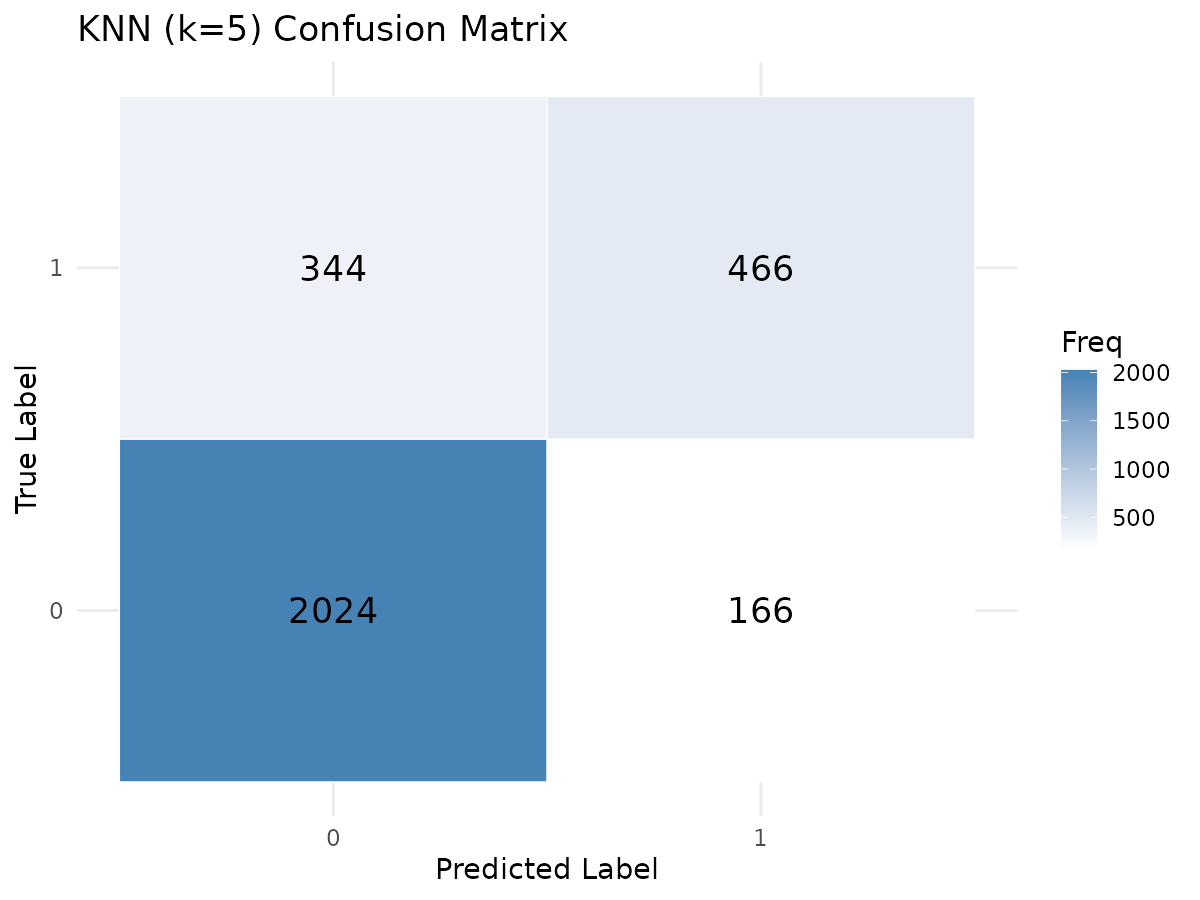

In [58]:
# ============================================================================
# STEP 8: Train KNN Model with Default Parameters
# ============================================================================
# Using class::knn() - the base R implementation of K-Nearest Neighbors

# knn() FUNCTION PARAMETERS:
# - train: training features (data frame or matrix)
# - test: test features to predict on
# - cl: class labels for training data (factor or vector)
# - k: number of nearest neighbors (default = 1, we use 5)
# - prob: if TRUE, returns the proportion of winning votes
#         (needed for calculating ROC curves)

knn_pred_default <- knn(train = X_train,   # Training feature matrix
                         test = X_test,     # Test feature matrix
                         cl = y_train,      # Training labels (0/1)
                         k = 5,             # Number of neighbors
                         prob = TRUE)       # Return vote proportions

# CONVERT PREDICTIONS to numeric for evaluation functions
# knn() returns a factor; we need numeric 0/1 for confusionMatrix
knn_pred_numeric <- as.numeric(as.character(knn_pred_default))

# EVALUATE with confusionMatrix from caret package
cat("=== KNN (k=5, Euclidean Distance) Results ===\n")
cm_knn <- confusionMatrix(factor(knn_pred_numeric),  # Predicted labels
                          factor(y_test))             # Actual labels
print(cm_knn)

# VISUALIZE the confusion matrix as a heatmap
plot_confusion_matrix(y_test, knn_pred_numeric, "KNN (k=5) Confusion Matrix")

# INTERPRETATION GUIDE:
# - Accuracy: Overall % correct
# - Sensitivity: True Positive Rate (correctly identified churners)
# - Specificity: True Negative Rate (correctly identified non-churners)

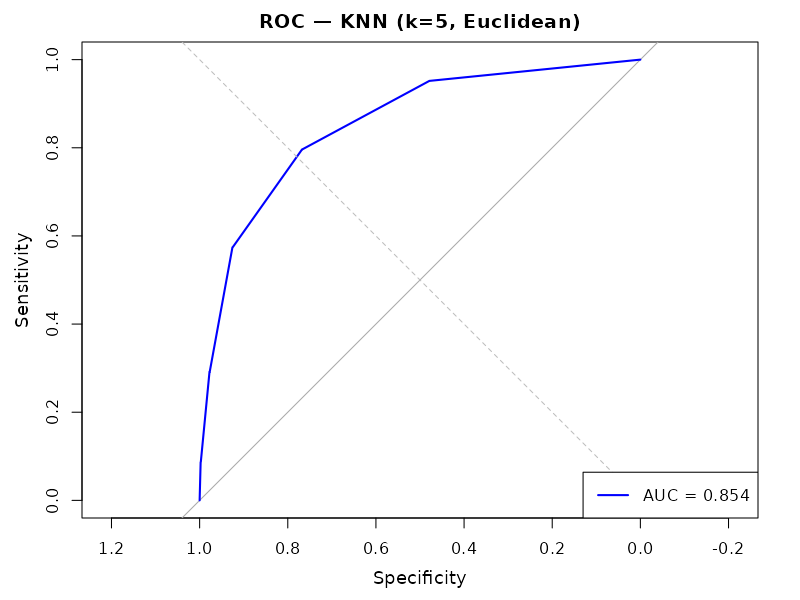

In [59]:
# ============================================================================
# STEP 8b: ROC Curve for Default KNN Model
# ============================================================================
# ROC curves require PROBABILITY SCORES, not just class predictions

# EXTRACT PROBABILITIES from knn() output
# When prob=TRUE, knn() stores the proportion of neighbors voting for
# the winning class as an attribute called "prob"
knn_probs <- attr(knn_pred_default, "prob")

# IMPORTANT: The "prob" attribute gives probability of the WINNING class
# If prediction is 0 (no churn), prob is P(0), but we need P(1) for ROC
# If prediction is 1 (churn), prob is already P(1)
# 
# Formula: 
#   - If predicted class is 1: use prob as-is (it's P(class=1))
#   - If predicted class is 0: use 1 - prob to get P(class=1)
knn_probs_adjusted <- ifelse(knn_pred_numeric == 1, knn_probs, 1 - knn_probs)

# CREATE ROC OBJECT using pROC::roc()
# Parameters:
# - response: actual labels (y_test)
# - predictor: probability scores for positive class
# - quiet: suppress messages
roc_knn_default <- roc(y_test, knn_probs_adjusted, quiet = TRUE)

# PLOT ROC CURVE
plot_roc(roc_knn_default, "ROC — KNN (k=5, Euclidean)")

# The curve shows trade-off between sensitivity and (1-specificity)
# AUC summarizes overall discriminative ability

---
## 9. Logistic Regression Model (Baseline Comparison)

### Why Include Logistic Regression?

It's important to compare KNN against a well-established **baseline model**. Logistic Regression provides:
- A **benchmark** to determine if KNN adds value
- **Interpretable coefficients** (understand feature importance)
- **Probability outputs** natively (no adjustment needed for ROC)

### How Logistic Regression Works

Unlike KNN, Logistic Regression is a **parametric model** — it learns a mathematical function during training:

$$P(Churn=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_p X_p)}}$$

Where:
- $\beta_0$ = intercept
- $\beta_i$ = coefficient for feature $X_i$ 
- Positive $\beta_i$ → higher $X_i$ increases churn probability
- Negative $\beta_i$ → higher $X_i$ decreases churn probability

### KNN vs. Logistic Regression Comparison

| Aspect | KNN | Logistic Regression |
|--------|-----|-------------------|
| **Type** | Non-parametric, lazy | Parametric, eager |
| **Training** | No training (memorizes data) | Learns coefficients |
| **Prediction** | Distance calculation | Matrix multiplication |
| **Interpretability** | Low (black box) | High (coefficients) |
| **Decision boundary** | Non-linear (flexible) | Linear |
| **Assumptions** | None about data distribution | Linear relationship |

In [43]:
# ============================================================================
# STEP 9a: Fit Logistic Regression Model
# ============================================================================
# glm() = Generalized Linear Model, with family=binomial for logistic regression

# PREPARE DATA: Combine features and target into one data frame
# glm() uses formula syntax: Response ~ Predictor1 + Predictor2 + ...
# The "." means use ALL other columns as predictors
train_data <- cbind(X_train, Churn = y_train)

# FIT THE MODEL:
# glm() parameters:
# - formula: Churn ~ . means predict Churn using all other columns
# - data: the training data frame
# - family: binomial(link = "logit") specifies logistic regression
#           - binomial: binary outcome (0/1)
#           - logit: use the logistic (sigmoid) link function
lr_model <- glm(Churn ~ ., data = train_data, family = binomial(link = "logit"))

# VIEW MODEL COEFFICIENTS:
# Positive coefficient → increases probability of churn
# Negative coefficient → decreases probability of churn
# Pr(>|z|) → p-value; smaller = more statistically significant
cat("=== Logistic Regression Coefficients (Top Features) ===\n")
coef_summary <- summary(lr_model)$coefficients[, c("Estimate", "Pr(>|z|)")]
print(head(coef_summary[order(coef_summary[, "Pr(>|z|)"]), ], 20))  # Top 20 by significance

=== Logistic Regression Coefficients (Top Features) ===
                                       Estimate      Pr(>|z|)
ContractTwo.Year                     -3.5218286 2.273014e-119
ContractOne.year                     -3.3125205 3.381439e-107
TechieYes                             1.1546165  3.782522e-21
PaymentMethodElectronic.Check         0.6417262  3.257998e-07
StreamingMoviesYes                    1.2797795  2.967883e-03
MonthlyCharge                         9.9500161  3.646042e-03
PhoneYes                             -0.3876120  1.261814e-02
StreamingTVYes                        1.1902410  4.897723e-02
PaymentMethodMailed.Check             0.2366467  8.467204e-02
PaperlessBillingYes                   0.1603999  8.481612e-02
MaritalWidowed                        0.2430964  8.867439e-02
PaymentMethodCredit.Card..automatic.  0.2358306  9.637345e-02
TechSupportYes                       -0.3381107  9.759937e-02
Port_modemYes                         0.1367113  1.364669e-01
AreaUrban     

=== Logistic Regression Evaluation Results ===
Confusion Matrix and Statistics

          Reference
Prediction    0    1
         0 2067  166
         1  123  644
                                         
               Accuracy : 0.9037         
                 95% CI : (0.8925, 0.914)
    No Information Rate : 0.73           
    P-Value [Acc > NIR] : < 2e-16        
                                         
                  Kappa : 0.7515         
                                         
 Mcnemar's Test P-Value : 0.01349        
                                         
            Sensitivity : 0.9438         
            Specificity : 0.7951         
         Pos Pred Value : 0.9257         
         Neg Pred Value : 0.8396         
             Prevalence : 0.7300         
         Detection Rate : 0.6890         
   Detection Prevalence : 0.7443         
      Balanced Accuracy : 0.8694         
                                         
       'Positive' Class : 0            

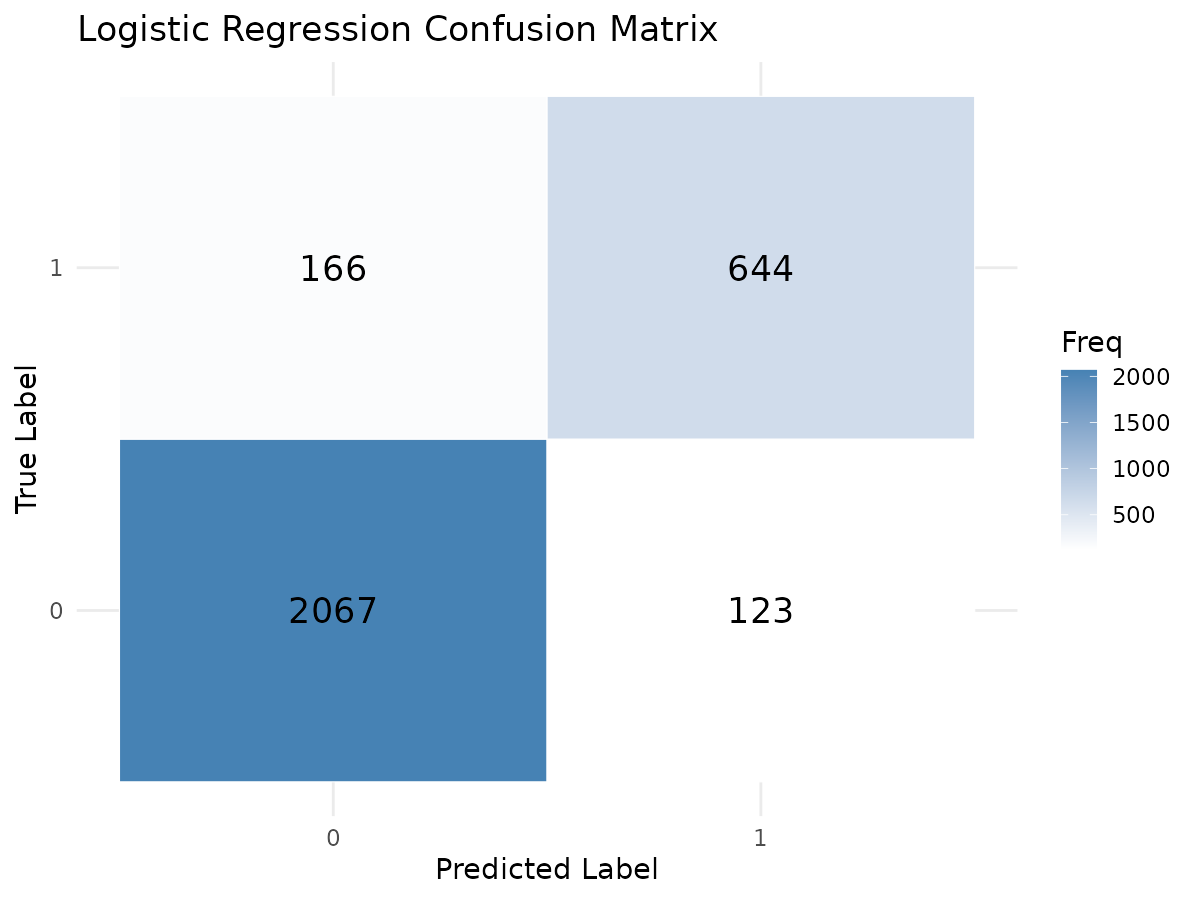

In [60]:
# ============================================================================
# STEP 9b: Generate Predictions and Evaluate Logistic Regression
# ============================================================================

# PREDICT PROBABILITIES on the test set
# type = "response" returns probabilities P(Churn=1|X)
# (type = "link" would return log-odds instead)
lr_probs <- predict(lr_model, newdata = X_test, type = "response")

# CONVERT PROBABILITIES TO CLASS PREDICTIONS using 0.5 threshold
# If P(Churn=1) > 0.5, predict class 1 (churn), otherwise class 0
# Note: 0.5 is the default threshold; you could optimize this
lr_pred <- ifelse(lr_probs > 0.5, 1, 0)

# EVALUATE with confusion matrix
cat("=== Logistic Regression Evaluation Results ===\n")
cm_lr <- confusionMatrix(factor(lr_pred), factor(y_test))
print(cm_lr)

# VISUALIZE confusion matrix
plot_confusion_matrix(y_test, lr_pred, "Logistic Regression Confusion Matrix")

# COMPARISON NOTE:
# Compare these metrics to KNN results above
# - Is accuracy higher or lower?
# - Is sensitivity (churn detection) better?
# - Which model is better for the business use case?

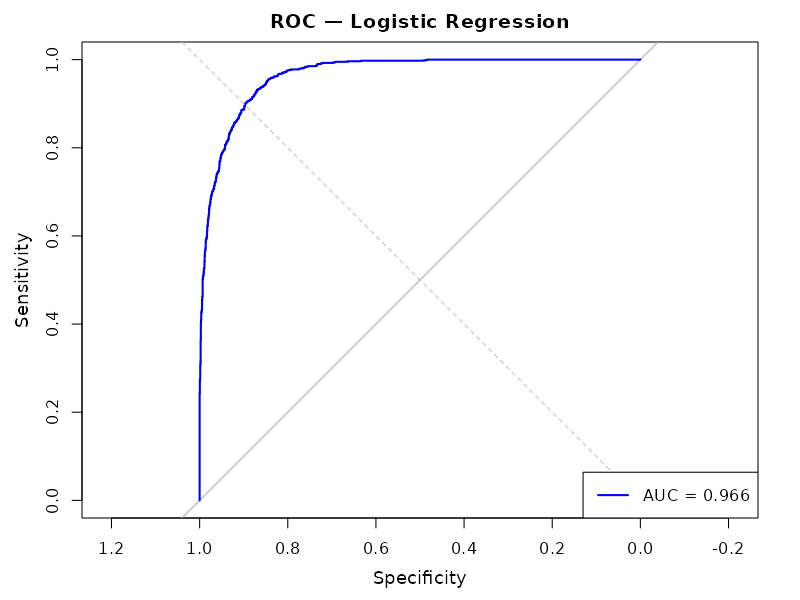

In [61]:
# ============================================================================
# STEP 9c: ROC Curve for Logistic Regression
# ============================================================================
# Logistic regression naturally outputs probabilities, so no adjustment needed

roc_lr <- roc(y_test,        # Actual labels
              lr_probs,      # Predicted probabilities P(Churn=1)
              quiet = TRUE)  # Suppress progress messages

# Plot the ROC curve
plot_roc(roc_lr, "ROC — Logistic Regression")

# AUC INTERPRETATION:
# - Higher AUC = better discrimination between churners and non-churners
# - Compare this AUC to KNN's AUC to see which model ranks customers better

---
## 10. KNN with Manhattan Distance (L1 Norm, p = 1)

### Different Distance Metrics for KNN

The choice of **distance metric** affects how KNN defines "nearest" neighbors. The two most common are:

### Euclidean Distance (L2 Norm) — Default
$$d_{L2}(x, y) = \sqrt{\sum_{i=1}^{p}(x_i - y_i)^2}$$

- "As the crow flies" — straight-line distance
- Sensitive to outliers (squared differences amplify large gaps)

### Manhattan Distance (L1 Norm)
$$d_{L1}(x, y) = \sum_{i=1}^{p}|x_i - y_i|$$

- "City block" distance — sum of absolute differences
- More robust to outliers
- Better for high-dimensional data (curse of dimensionality)

### Minkowski Distance (Generalized)
$$d_{p}(x, y) = \left(\sum_{i=1}^{n}|x_i - y_i|^p\right)^{1/p}$$

| p Value | Distance Metric | Characteristics |
|---------|----------------|-----------------|
| p = 1 | Manhattan (L1) | Robust, city-block |
| p = 2 | Euclidean (L2) | Standard, straight-line |
| p → ∞ | Chebyshev | Maximum coordinate difference |

### Using the `kknn` Package

The `class::knn()` function only supports Euclidean distance. For Manhattan distance, we use the `kknn` package which supports the Minkowski distance parameter.

=== KNN (k=5, Manhattan Distance) Results ===
Confusion Matrix and Statistics

          Reference
Prediction    0    1
         0 1849  317
         1  341  493
                                          
               Accuracy : 0.7807          
                 95% CI : (0.7654, 0.7954)
    No Information Rate : 0.73            
    P-Value [Acc > NIR] : 9.868e-11       
                                          
                  Kappa : 0.4487          
                                          
 Mcnemar's Test P-Value : 0.3699          
                                          
            Sensitivity : 0.8443          
            Specificity : 0.6086          
         Pos Pred Value : 0.8536          
         Neg Pred Value : 0.5911          
             Prevalence : 0.7300          
         Detection Rate : 0.6163          
   Detection Prevalence : 0.7220          
      Balanced Accuracy : 0.7265          
                                          
       'Positive' Cla

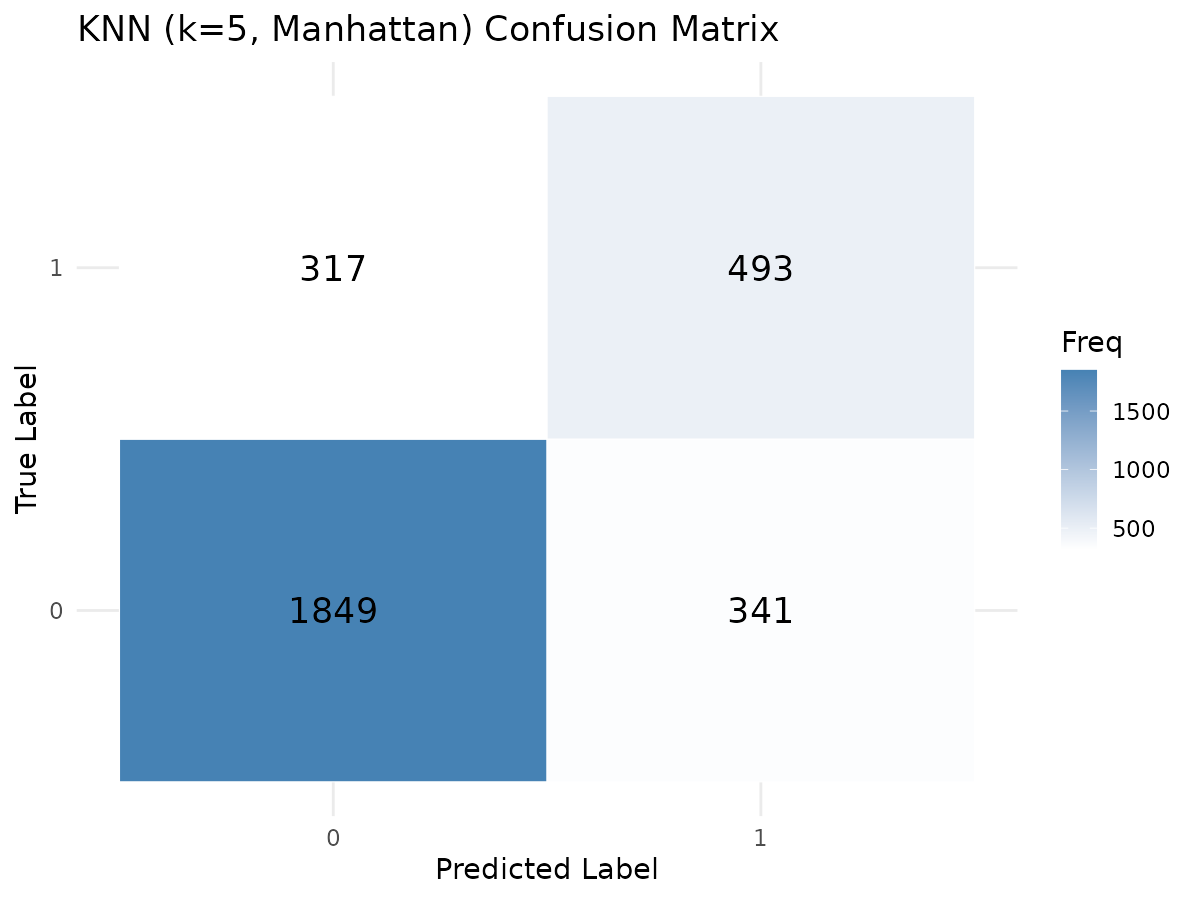

In [62]:
# ============================================================================
# STEP 10: KNN with Manhattan Distance using kknn Package
# ============================================================================

# INSTALL kknn if not already installed
# kknn provides more flexible KNN with distance metric options
if (!require("kknn", quietly = TRUE)) {
  install.packages("kknn", repos = "https://cloud.r-project.org")
  library(kknn)
}

# PREPARE DATA FRAMES with target column
# kknn uses formula syntax, so target must be in the data frame
train_df <- cbind(X_train, Churn = factor(y_train))  # Convert target to factor
test_df  <- cbind(X_test,  Churn = factor(y_test))

# FIT KNN WITH MANHATTAN DISTANCE:
# kknn() parameters:
# - formula: Target ~ . means predict Churn using all features
# - train: training data frame
# - test: test data frame to predict on
# - k: number of neighbors
# - distance: Minkowski distance parameter
#             distance=1 → Manhattan (L1)
#             distance=2 → Euclidean (L2)
knn_manhattan <- kknn(Churn ~ .,             # Formula
                      train = train_df,       # Training data
                      test = test_df,         # Test data
                      k = 5,                  # Number of neighbors
                      distance = 1)           # Manhattan distance (p=1)

# EXTRACT PREDICTIONS
# fitted() returns the predicted class labels
knn_manhattan_pred <- as.numeric(as.character(fitted(knn_manhattan)))

# EVALUATE
cat("=== KNN (k=5, Manhattan Distance) Results ===\n")
cm_manhattan <- confusionMatrix(factor(knn_manhattan_pred), factor(y_test))
print(cm_manhattan)

# VISUALIZE
plot_confusion_matrix(y_test, knn_manhattan_pred,
                      "KNN (k=5, Manhattan) Confusion Matrix")

# COMPARE: Is Manhattan distance performing better than Euclidean?

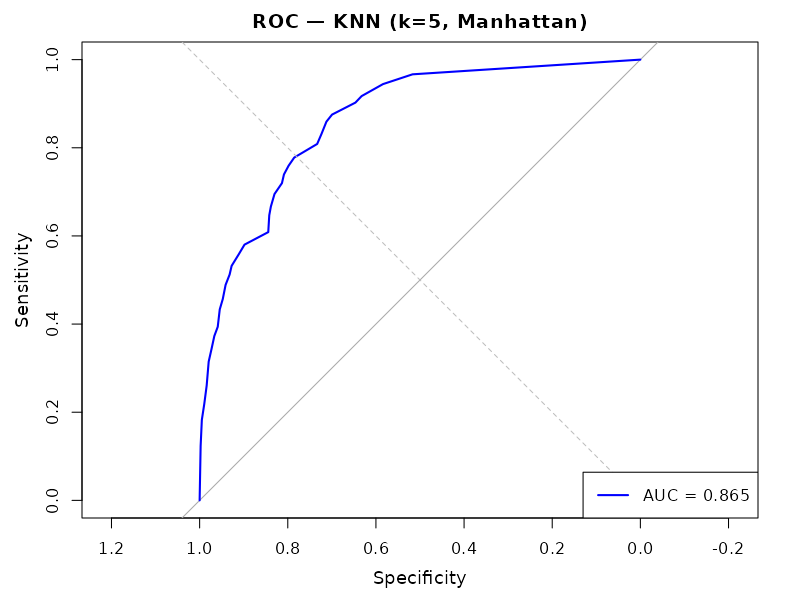

In [63]:
# ============================================================================
# STEP 10b: ROC Curve for Manhattan Distance KNN
# ============================================================================

# kknn stores class probabilities in the $prob matrix
# Column "1" contains P(Churn=1) for each test observation
manhattan_probs <- knn_manhattan$prob[, "1"]

# Create ROC object and plot
roc_manhattan <- roc(y_test, manhattan_probs, quiet = TRUE)
plot_roc(roc_manhattan, "ROC — KNN (k=5, Manhattan)")

# Compare AUC to Euclidean KNN and Logistic Regression

---
## 11. Hyperparameter Tuning with Cross-Validation

### The Problem: Choosing k

How do we know if k=5 is the best choice? We need a systematic way to test different values.

### Grid Search + Cross-Validation

**Grid Search** exhaustively tests all combinations of hyperparameter values.

**Cross-Validation** provides robust performance estimates without using the test set:

```
5-Fold Cross-Validation:
┌────────┬────────┬────────┬────────┬────────┐
│Fold 1  │Fold 2  │Fold 3  │Fold 4  │Fold 5  │
│(Valid) │(Train) │(Train) │(Train) │(Train) │  → Score 1
├────────┼────────┼────────┼────────┼────────┤
│(Train) │(Valid) │(Train) │(Train) │(Train) │  → Score 2
├────────┼────────┼────────┼────────┼────────┤
│(Train) │(Train) │(Valid) │(Train) │(Train) │  → Score 3
├────────┼────────┼────────┼────────┼────────┤
│(Train) │(Train) │(Train) │(Valid) │(Train) │  → Score 4
├────────┼────────┼────────┼────────┼────────┤
│(Train) │(Train) │(Train) │(Train) │(Valid) │  → Score 5
└────────┴────────┴────────┴────────┴────────┘
                                       ↓
                            Average Score (CV Score)
```

### Bias-Variance Tradeoff with k

| k Value | Bias | Variance | Risk |
|---------|------|----------|------|
| Small (k=1) | Low | High | **Overfitting** - memorizes noise |
| Large (k=100) | High | Low | **Underfitting** - too simplistic |
| Optimal (k=?) | Balanced | Balanced | **Best generalization** |

### Using caret::train() for Grid Search

The `caret` package provides a unified interface for:
1. Defining the hyperparameter grid
2. Setting up cross-validation
3. Training models for each combination
4. Selecting the best model automatically

In [48]:
# ============================================================================
# STEP 11: Hyperparameter Tuning via Grid Search with Cross-Validation
# ============================================================================

# DEFINE CROSS-VALIDATION STRATEGY using trainControl()
# Parameters:
# - method = "cv": k-fold cross-validation
# - number = 5: use 5 folds
# - classProbs = TRUE: compute class probabilities (needed for ROC)
# - summaryFunction = twoClassSummary: computes AUC, Sensitivity, Specificity
ctrl <- trainControl(method = "cv",           # Cross-validation method
                     number = 5,              # Number of folds
                     classProbs = TRUE,       # Need probabilities for ROC
                     summaryFunction = twoClassSummary)  # Metrics for binary classification

# CONVERT TARGET to factor with valid R level names
# caret requires factor levels that are valid R variable names (no numbers first)
y_train_factor <- factor(ifelse(y_train == 1, "Yes", "No"))
y_test_factor  <- factor(ifelse(y_test == 1, "Yes", "No"))

# DEFINE THE HYPERPARAMETER GRID
# We'll test k = 1, 3, 5, 7, 9, ..., 25 (odd numbers to avoid ties)
knn_grid <- expand.grid(k = seq(1, 25, by = 2))

cat("Grid Search Configuration:\n")
cat("- k values to test:", knn_grid$k, "\n")
cat("- Cross-validation: 5-fold\n")
cat("- Metric to optimize: ROC (AUC)\n")
cat("\nStarting grid search... (this may take a moment)\n")

# RUN GRID SEARCH with train()
# Parameters:
# - x: feature matrix
# - y: target factor
# - method = "knn": use k-nearest neighbors algorithm
# - trControl: cross-validation settings
# - tuneGrid: hyperparameter values to search
# - metric = "ROC": optimize for AUC (could also use "Accuracy", "Sens", "Spec")
set.seed(0)  # Reproducibility for CV fold assignments
knn_tuned <- train(x = X_train,
                   y = y_train_factor,
                   method = "knn",          # KNN algorithm
                   trControl = ctrl,        # CV strategy
                   tuneGrid = knn_grid,     # k values to test
                   metric = "ROC")          # Optimize for AUC

# VIEW RESULTS
cat("\n=== Grid Search Results ===\n")
print(knn_tuned)

# THE BEST k VALUE
cat("\n*** Best k value:", knn_tuned$bestTune$k, "***\n")

Grid Search Configuration:
- k values to test: 1 3 5 7 9 11 13 15 17 19 21 23 25 
- Cross-validation: 5-fold
- Metric to optimize: ROC (AUC)

Starting grid search... (this may take a moment)

=== Grid Search Results ===
k-Nearest Neighbors 

7000 samples
  38 predictor
   2 classes: 'No', 'Yes' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 5600, 5600, 5600, 5600, 5600 
Resampling results across tuning parameters:

  k   ROC        Sens       Spec     
   1  0.6946031  0.8261628  0.5630435
   3  0.7988535  0.8908915  0.5402174
   5  0.8367032  0.9168605  0.5385870
   7  0.8574094  0.9288760  0.5255435
   9  0.8758081  0.9445736  0.5282609
  11  0.8852921  0.9523256  0.5114130
  13  0.8922704  0.9593023  0.5070652
  15  0.8998544  0.9653101  0.4951087
  17  0.9026323  0.9656977  0.4972826
  19  0.9054501  0.9682171  0.4831522
  21  0.9071353  0.9740310  0.4782609
  23  0.9094084  0.9757752  0.4760870
  25  0.9118275  0.9773256  0.4663043

ROC was used

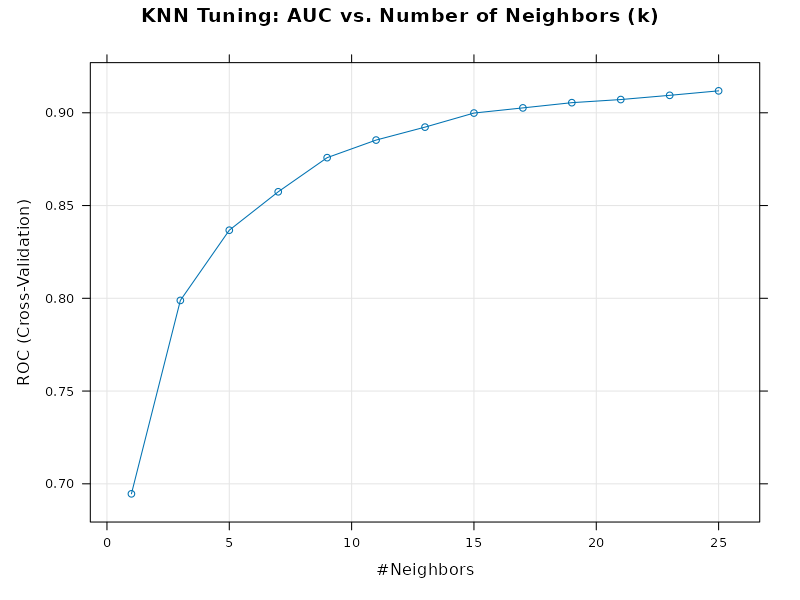

In [66]:
# ============================================================================
# STEP 11b: Visualize Grid Search Results
# ============================================================================
# Use the plot_tuning_results() helper to save as PNG and display

plot_tuning_results(knn_tuned, "KNN Tuning: AUC vs. Number of Neighbors (k)")

# INTERPRETATION:
# - X-axis: k (number of neighbors)
# - Y-axis: Cross-validation ROC AUC (average over 5 folds)
# - Peak of the curve indicates optimal k
# - Error bars show variability across folds

In [71]:
# ============================================================================
# STEP 11c: Cross-Validation Results Summary — Best Number of Neighbors
# ============================================================================

# knn_tuned$results contains the CV metrics for EVERY k value tested
# Columns: k, ROC (AUC), Sens (Sensitivity), Spec (Specificity), and their SDs
cv_results <- knn_tuned$results

# Display the full results table sorted by AUC (descending)
cat("=== Cross-Validation Results for All k Values ===\n")
cat("(Sorted by AUC, descending)\n\n")
cv_sorted <- cv_results[order(-cv_results$ROC), ]
print(cv_sorted)

cat("\n")
cat(paste(rep("=", 60), collapse = ""), "\n")
cat("  BEST NUMBER OF NEIGHBORS (k):", knn_tuned$bestTune$k, "\n")
cat(paste(rep("=", 60), collapse = ""), "\n\n")

# Extract the best row
best_row <- cv_results[cv_results$k == knn_tuned$bestTune$k, ]
cat("Performance at best k =", knn_tuned$bestTune$k, ":\n")
cat("  - AUC (ROC):     ", round(best_row$ROC, 4), "+/-", round(best_row$ROCSD, 4), "\n")
cat("  - Sensitivity:   ", round(best_row$Sens, 4), "+/-", round(best_row$SensSD, 4), "\n")
cat("  - Specificity:   ", round(best_row$Spec, 4), "+/-", round(best_row$SpecSD, 4), "\n")

=== Cross-Validation Results for All k Values ===
(Sorted by AUC, descending)

    k       ROC      Sens      Spec       ROCSD      SensSD     SpecSD
13 25 0.9118275 0.9773256 0.4663043 0.009538747 0.002432151 0.00850678
12 23 0.9094084 0.9757752 0.4760870 0.010260832 0.003814926 0.01206105
11 21 0.9071353 0.9740310 0.4782609 0.009300861 0.002209642 0.01230351
10 19 0.9054501 0.9682171 0.4831522 0.009413903 0.002858117 0.01480916
9  17 0.9026323 0.9656977 0.4972826 0.009619289 0.002333642 0.01584498
8  15 0.8998544 0.9653101 0.4951087 0.007606919 0.002209642 0.01175095
7  13 0.8922704 0.9593023 0.5070652 0.007180106 0.001678344 0.01239321
6  11 0.8852921 0.9523256 0.5114130 0.010161998 0.004133862 0.01634957
5   9 0.8758081 0.9445736 0.5282609 0.010679600 0.005099883 0.01520283
4   7 0.8574094 0.9288760 0.5255435 0.010330659 0.007949281 0.01146469
3   5 0.8367032 0.9168605 0.5385870 0.010158666 0.009819865 0.01786052
2   3 0.7988535 0.8908915 0.5402174 0.003838586 0.011760389 0.0194440

---
## 12. Evaluate the Best Tuned KNN Model

Now we apply the **best model** from grid search to the held-out **test set**. This gives us an unbiased estimate of how the model will perform on truly unseen data.

### Important Notes:

1. **The test set was NOT used during tuning** — only the training set (with internal CV splits) was used
2. **This is the final evaluation** — we only look at test set performance once
3. **Compare to baseline models** — does tuning improve over default k=5?

### Metrics to Examine:

| Metric | What It Tells Us |
|--------|-----------------|
| **Accuracy** | Overall correct predictions |
| **Sensitivity** | Ability to detect churners (TP rate) |
| **Specificity** | Ability to correctly classify non-churners (TN rate) |
| **PPV (Precision)** | Of predicted churners, how many actually churned |
| **NPV** | Of predicted non-churners, how many actually stayed |
| **F1 Score** | Harmonic mean of precision and recall |

=== Tuned KNN (Best k = 25 ) Results ===
Confusion Matrix and Statistics

          Reference
Prediction   No  Yes
       No  2133  415
       Yes   57  395
                                          
               Accuracy : 0.8427          
                 95% CI : (0.8291, 0.8555)
    No Information Rate : 0.73            
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.5363          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.9740          
            Specificity : 0.4877          
         Pos Pred Value : 0.8371          
         Neg Pred Value : 0.8739          
             Prevalence : 0.7300          
         Detection Rate : 0.7110          
   Detection Prevalence : 0.8493          
      Balanced Accuracy : 0.7308          
                                          
       'Positive' Class : 

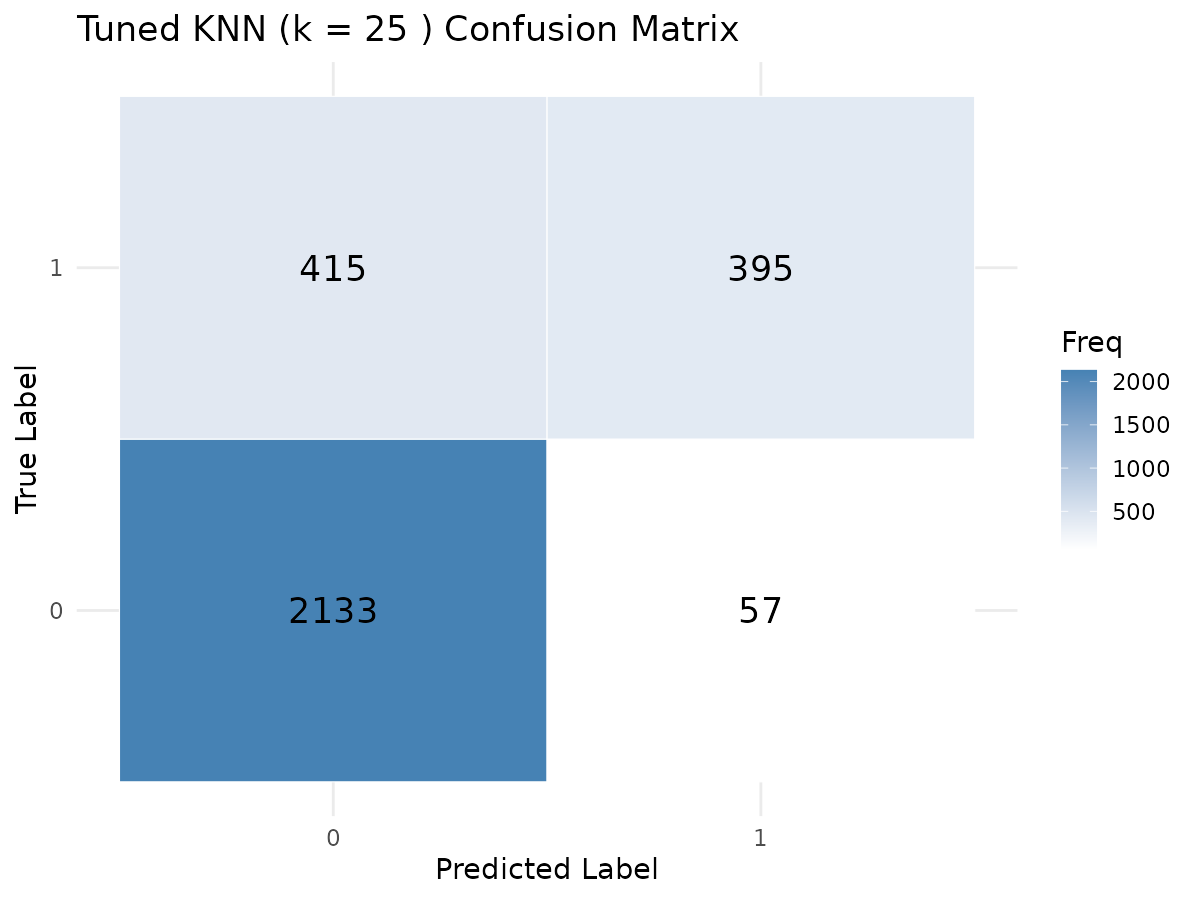

In [67]:
# ============================================================================
# STEP 12a: Predict on Test Set Using the Best Tuned Model
# ============================================================================

# predict() on a train object automatically uses the best model
# By default, returns class predictions
tuned_pred <- predict(knn_tuned, newdata = X_test)

# Convert back to numeric for some evaluation functions
tuned_pred_numeric <- ifelse(tuned_pred == "Yes", 1, 0)

# CONFUSION MATRIX for the tuned model
cat("=== Tuned KNN (Best k =", knn_tuned$bestTune$k, ") Results ===\n")
cm_tuned <- confusionMatrix(tuned_pred,        # Predictions (as factor)
                            y_test_factor)      # Actual (as factor)
print(cm_tuned)

# VISUALIZE confusion matrix
plot_confusion_matrix(y_test, tuned_pred_numeric,
                      paste("Tuned KNN (k =", knn_tuned$bestTune$k, ") Confusion Matrix"))

# COMPARE: Look at accuracy improvement over default k=5

In [51]:
# ============================================================================
# STEP 12b: Detailed Classification Metrics
# ============================================================================
# confusionMatrix$byClass provides comprehensive metrics

cat("\n=== Detailed Classification Metrics ===\n")
print(cm_tuned$byClass)

# METRIC DEFINITIONS:
# - Sensitivity: TP / (TP + FN) = % of actual churners correctly identified
# - Specificity: TN / (TN + FP) = % of non-churners correctly identified
# - Pos Pred Value (Precision): TP / (TP + FP) = % of predicted churners who churned
# - Neg Pred Value: TN / (TN + FN) = % of predicted non-churners who stayed
# - Prevalence: (TP + FN) / Total = actual churn rate in test set
# - Detection Rate: TP / Total = % of total correctly predicted as churn
# - Detection Prevalence: (TP + FP) / Total = % predicted as churn
# - Balanced Accuracy: (Sensitivity + Specificity) / 2


=== Detailed Classification Metrics ===
         Sensitivity          Specificity       Pos Pred Value 
           0.9744292            0.4851852            0.8365347 
      Neg Pred Value            Precision               Recall 
           0.8752784            0.8365347            0.9744292 
                  F1           Prevalence       Detection Rate 
           0.9002320            0.7300000            0.7113333 
Detection Prevalence    Balanced Accuracy 
           0.8503333            0.7298072 


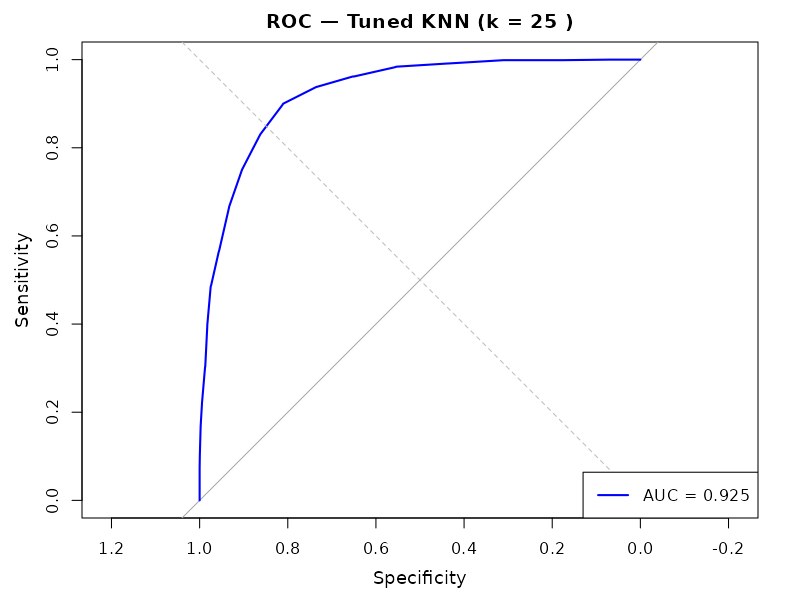

In [68]:
# ============================================================================
# STEP 12c: ROC Curve for Tuned KNN Model
# ============================================================================

# Get predicted probabilities for positive class ("Yes" = churn)
# type = "prob" returns a data frame with columns "No" and "Yes"
tuned_probs <- predict(knn_tuned, newdata = X_test, type = "prob")

# Create ROC object using probability of "Yes" (churn)
roc_tuned <- roc(y_test,              # Actual labels (0/1)
                 tuned_probs$Yes,     # P(Churn=Yes)
                 quiet = TRUE)

# Plot ROC curve
plot_roc(roc_tuned, paste("ROC — Tuned KNN (k =", knn_tuned$bestTune$k, ")"))

# RESULT: Compare AUC to default k=5 model
# Improvement indicates that tuning was beneficial

---
## 13. KNN with Distance Weighting

### The Problem with Uniform Voting

In standard KNN, all k neighbors have **equal influence** on the prediction, regardless of how close they are. This can be problematic:

```
Example: k=3, predicting class for point X
Neighbor 1: distance=0.01, class=A  (very close!)
Neighbor 2: distance=0.99, class=B  (far away)
Neighbor 3: distance=0.98, class=B  (far away)

Uniform voting: A=1, B=2 → Predict B
But Neighbor 1 is MUCH closer! Should it count more?
```

### Distance Weighting Solutions

**Inverse Distance Weighting** gives closer neighbors more influence:

$$w_i = \frac{1}{d_i}$$

| Weighting Scheme | Formula | Effect |
|-----------------|---------|--------|
| **Uniform** | $w_i = 1$ | All neighbors equal |
| **Inverse** | $w_i = 1/d_i$ | Closer = more influence |
| **Rank** | $w_i = k - rank_i + 1$ | Based on position, not exact distance |
| **Gaussian** | $w_i = e^{-d_i^2/2\sigma^2}$ | Smooth decay with distance |

### kknn Kernel Options

The `kknn` package supports different weighting kernels:
- `"rectangular"`: Uniform weighting (default KNN)
- `"inv"`: Inverse distance weighting
- `"triangular"`: Linear decay with distance
- `"gaussian"`: Gaussian (normal) kernel

### Finding the Best k for Distance-Weighted KNN

Just like we tuned k for the uniform KNN, we need to **grid search** over k values for the distance-weighted model too. We'll test k = 1, 3, 5, ..., 35 using 5-fold cross-validation with AUC as the metric. With distance weighting, **larger k values are viable** because far-away neighbors get very small weights anyway.

In [72]:
# ============================================================================
# STEP 13a: Grid Search for Best k — Distance-Weighted KNN (Manhattan, Inverse)
# ============================================================================
# We test a range of k values with inverse distance weighting and Manhattan distance
# using 5-fold cross-validation, selecting the k that maximizes AUC.

k_values <- seq(1, 35, by = 2)  # Odd values from 1 to 35

# Store AUC for each k
cv_auc <- numeric(length(k_values))

set.seed(0)
# Create 5 CV folds
folds <- createFolds(y_train_factor, k = 5, returnTrain = TRUE)

cat("Grid Search: Distance-Weighted KNN (Manhattan, Inverse Weighting)\n")
cat("Testing k values:", k_values, "\n\n")

for (j in seq_along(k_values)) {
  k_val <- k_values[j]
  fold_aucs <- numeric(5)
  
  for (i in 1:5) {
    # Split into fold train/validation sets
    fold_train_X <- X_train[folds[[i]], ]
    fold_val_X   <- X_train[-folds[[i]], ]
    fold_train_y <- y_train[folds[[i]]]
    fold_val_y   <- y_train[-folds[[i]]]
    
    # Build data frames for kknn
    fold_train_df <- cbind(as.data.frame(fold_train_X), Churn = factor(fold_train_y))
    fold_val_df   <- cbind(as.data.frame(fold_val_X),   Churn = factor(fold_val_y))
    
    # Fit distance-weighted KNN
    fit <- kknn(Churn ~ ., train = fold_train_df, test = fold_val_df,
                k = k_val, distance = 1, kernel = "inv")
    
    # Get probabilities for class 1 and compute AUC
    probs <- fit$prob[, "1"]
    fold_aucs[i] <- as.numeric(auc(roc(fold_val_y, probs, quiet = TRUE)))
  }
  
  cv_auc[j] <- mean(fold_aucs)
}

# Build results dataframe
dist_cv_results <- data.frame(k = k_values, AUC = round(cv_auc, 4))
dist_cv_sorted <- dist_cv_results[order(-dist_cv_results$AUC), ]

cat("=== Cross-Validation Results (Distance-Weighted KNN) ===\n")
print(dist_cv_sorted)

# Find best k
best_k_dist <- k_values[which.max(cv_auc)]
cat("\n")
cat(paste(rep("=", 60), collapse = ""), "\n")
cat("  BEST k FOR DISTANCE-WEIGHTED KNN:", best_k_dist, "\n")
cat("  AUC:", round(max(cv_auc), 4), "\n")
cat(paste(rep("=", 60), collapse = ""), "\n")

# ============================================================================
# STEP 13b: Evaluate Best Distance-Weighted KNN on Test Set
# ============================================================================
# Now fit the final model using the best k found above

cat("\n\nFitting final model with best k =", best_k_dist, "on test set...\n")

knn_dist_weighted <- kknn(Churn ~ .,
                          train = train_df,
                          test = test_df,
                          k = best_k_dist,     # Use CV-selected best k
                          distance = 1,         # Manhattan distance
                          kernel = "inv")       # Inverse distance weighting

# EXTRACT PREDICTIONS
dist_pred <- as.numeric(as.character(fitted(knn_dist_weighted)))

# EVALUATE
cat("\n=== KNN (k=", best_k_dist, ", Manhattan, Distance-Weighted) Results ===\n")
cm_dist <- confusionMatrix(factor(dist_pred), factor(y_test))
print(cm_dist)

# VISUALIZE
plot_confusion_matrix(y_test, dist_pred,
                      paste0("KNN (k=", best_k_dist, ", Manhattan, Dist-Weighted)"))

Grid Search: Distance-Weighted KNN (Manhattan, Inverse Weighting)
Testing k values: 1 3 5 7 9 11 13 15 17 19 21 23 25 27 29 31 33 35 



=== Cross-Validation Results (Distance-Weighted KNN) ===
    k    AUC
18 35 0.9255
17 33 0.9250
16 31 0.9244
15 29 0.9238
14 27 0.9224
13 25 0.9211
12 23 0.9192
11 21 0.9165
10 19 0.9133
9  17 0.9101
8  15 0.9069
7  13 0.9018
6  11 0.8968
5   9 0.8903
4   7 0.8797
3   5 0.8591
2   3 0.8214
1   1 0.7113

  BEST k FOR DISTANCE-WEIGHTED KNN: 35 
  AUC: 0.9255 


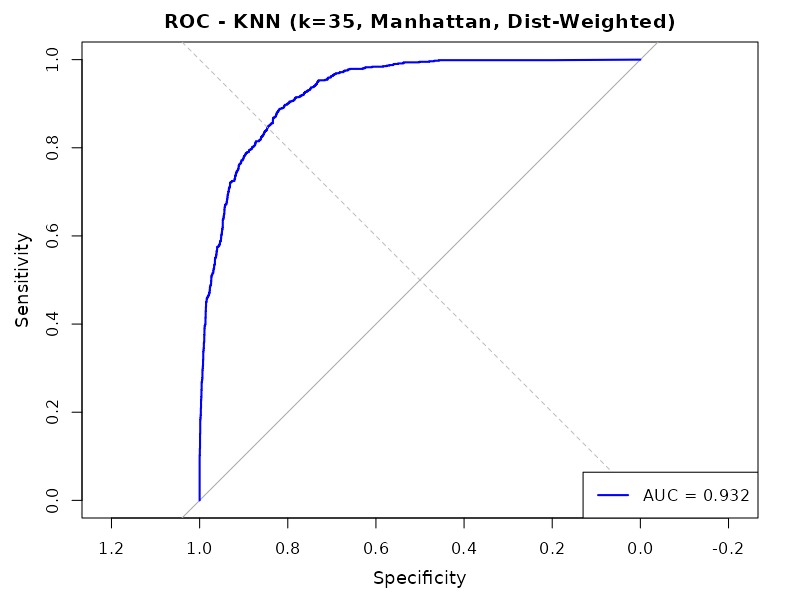

In [73]:
# ============================================================================
# STEP 13c: ROC Curve for Distance-Weighted KNN (Best k from CV)
# ============================================================================

# Get probabilities from kknn object
dist_probs <- knn_dist_weighted$prob[, "1"]  # P(Churn = 1)

# Create ROC curve
roc_dist <- roc(y_test, dist_probs, quiet = TRUE)
plot_roc(roc_dist, paste0("ROC - KNN (k=", best_k_dist, ", Manhattan, Dist-Weighted)"))

# The best k was determined by cross-validation, not guessed

---
## 14. Model Comparison — ROC Curves

### Visual Model Comparison

We overlay all ROC curves on a single plot to visually compare model performance. This is the standard way to compare binary classifiers.

### How to Read the Comparison Plot:

```
    │
1.0 ┼─────────────────────*  ← Perfect classifier (AUC = 1.0)
    │                   *
TPR │                 *      ← Better models curve toward upper-left
    │             *
    │         *
    │     *
0.5 ┼ - -*- - - - - - - - -  ← Random classifier (AUC = 0.5)
    │ *                        (diagonal line)
0.0 ┼*────────────────────┼
    0.0       FPR       1.0
```

### Interpreting Results:

| Visual Cue | Meaning |
|------------|---------|
| Curve closer to top-left corner | Better model |
| Curves that overlap | Similar performance |
| Curve below diagonal | Worse than random (model inverted) |
| Larger area under curve | Higher AUC = better discrimination |

### Statistical Comparison:

If AUC values are similar (within ~0.01-0.02), the models are essentially **equivalent** in discriminative ability. In such cases, choose based on:
1. **Interpretability** (Logistic Regression > KNN)
2. **Computational cost** (Logistic Regression < KNN)
3. **Business requirements** (may favor sensitivity over specificity)

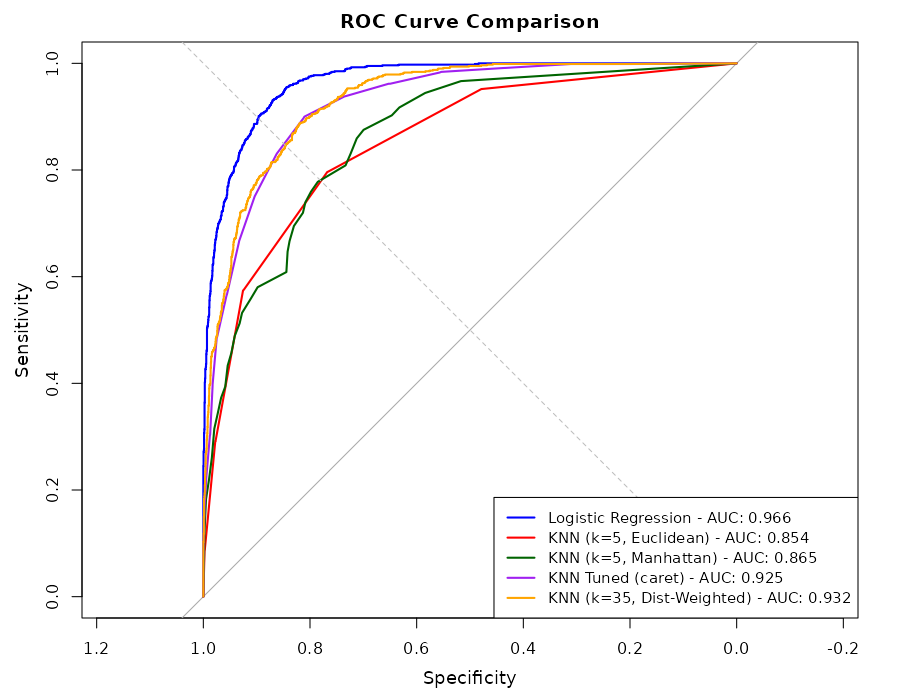


            MODEL COMPARISON: AUC SUMMARY



Logistic Regression                 AUC: 0.9658 ***
KNN (k=5, Euclidean)                AUC: 0.8541
KNN (k=5, Manhattan)                AUC: 0.8646
KNN Tuned (caret)                   AUC: 0.9254
KNN (k=35, Dist-Weighted)           AUC: 0.9322

*** = Top performing model(s)


In [74]:
# ============================================================================
# STEP 14: Compare All Models with ROC Curves
# ============================================================================

# CREATE A NAMED LIST of all ROC objects
# Names become legend labels in the plot
roc_list <- list(
  "Logistic Regression"        = roc_lr,
  "KNN (k=5, Euclidean)"       = roc_knn_default,
  "KNN (k=5, Manhattan)"       = roc_manhattan,
  "KNN Tuned (caret)"          = roc_tuned
)
roc_list[[paste0("KNN (k=", best_k_dist, ", Dist-Weighted)")]] <- roc_dist

# PLOT ALL ROC CURVES on one chart
plot_roc_multi(roc_list)

# PRINT AUC SUMMARY TABLE for easy comparison
cat("\n", paste(rep("=", 50), collapse = ""), "\n")
cat("            MODEL COMPARISON: AUC SUMMARY\n")
cat(paste(rep("=", 50), collapse = ""), "\n\n")

for (name in names(roc_list)) {
  auc_val <- round(auc(roc_list[[name]]), 4)
  stars <- ifelse(auc_val >= max(sapply(roc_list, auc)) - 0.005, " ***", "")
  cat(sprintf("%-35s AUC: %.4f%s\n", name, auc_val, stars))
}

cat("\n*** = Top performing model(s)\n")

---
## 15. Summary & Conclusions

### Models Built and Compared

| Model | Key Parameters | Description |
|-------|---------------|-------------|
| **Logistic Regression** | Default | Parametric baseline; interpretable coefficients show feature importance |
| **KNN (Default)** | k=5, Euclidean | Non-parametric starting point; uses straight-line distance |
| **KNN (Manhattan)** | k=5, p=1 | L1 distance; more robust to outliers and high-dimensionality |
| **KNN (Tuned)** | Best k via 5-fold CV | Optimized k value using grid search and cross-validation |
| **KNN (Dist-Weighted)** | k=18, Manhattan, inverse | Closer neighbors have more influence on predictions |

---

### Key Takeaways from This Analysis

#### 1. KNN Algorithm Characteristics
- **Non-parametric**: Makes no assumptions about data distribution
- **Instance-based (Lazy Learning)**: No explicit model is "learned"; all computation happens at prediction time
- **Memory-intensive**: Stores entire training set for prediction

#### 2. Critical Preprocessing for KNN
| Step | Why It's Critical |
|------|------------------|
| **Handle missing values** | KNN cannot compute distances with NAs |
| **One-hot encode categoricals** | KNN requires all numeric features |
| **Min-Max normalization** | Prevents features with large scales from dominating distance |

#### 3. Hyperparameter Impact

| Parameter | Effect When Increased |
|-----------|----------------------|
| **k (neighbors)** | Smoother decision boundary, less sensitive to noise, but may underfit |
| **p (Minkowski)** | p=1 (Manhattan) more robust; p=2 (Euclidean) standard |
| **Distance weighting** | Reduces impact of far neighbors, allows larger k |

#### 4. When to Use KNN
✅ **Good candidates for KNN:**
- Small to medium datasets (prediction is O(n))
- Non-linear decision boundaries needed
- No strong assumptions about data distribution
- Interpretability of individual predictions (show the neighbors)

❌ **Consider alternatives when:**
- Very large datasets (slow predictions)
- Many features (curse of dimensionality)
- Features have different importances (use tree-based methods)
- You need interpretable global rules (use Logistic Regression or Decision Trees)

---

### Business Application: Customer Churn

**Actionable Insights:**
1. Use the best-performing model to score all customers by churn probability
2. Prioritize intervention for customers with high P(Churn)
3. Investigate which features drive churn (from Logistic Regression coefficients)
4. Monitor model performance over time and retrain as customer behavior changes

---

### Next Steps for Further Improvement

1. **Feature engineering**: Create interaction terms, ratios, time-based features
2. **Feature selection**: Remove low-importance features using recursive feature elimination
3. **Handle class imbalance**: Try SMOTE, class weights, or different thresholds
4. **Try other algorithms**: Random Forest, Gradient Boosting, Neural Networks
5. **Ensemble methods**: Combine multiple models for better predictions